📂 加载数据: ODP_01_qhlazec_3d_validated_minimal.mat
✅ 数据加载完成。维度: (384, 336, 256, 351)
✅ 总通道数: 351
✅ 验证通过：通道数与描述 (351) 完全一致！
   -> Index 350 是最后一个通道 (QSM)，配置正确。
正在扫描 Sagittal 方向的大脑截面大小...


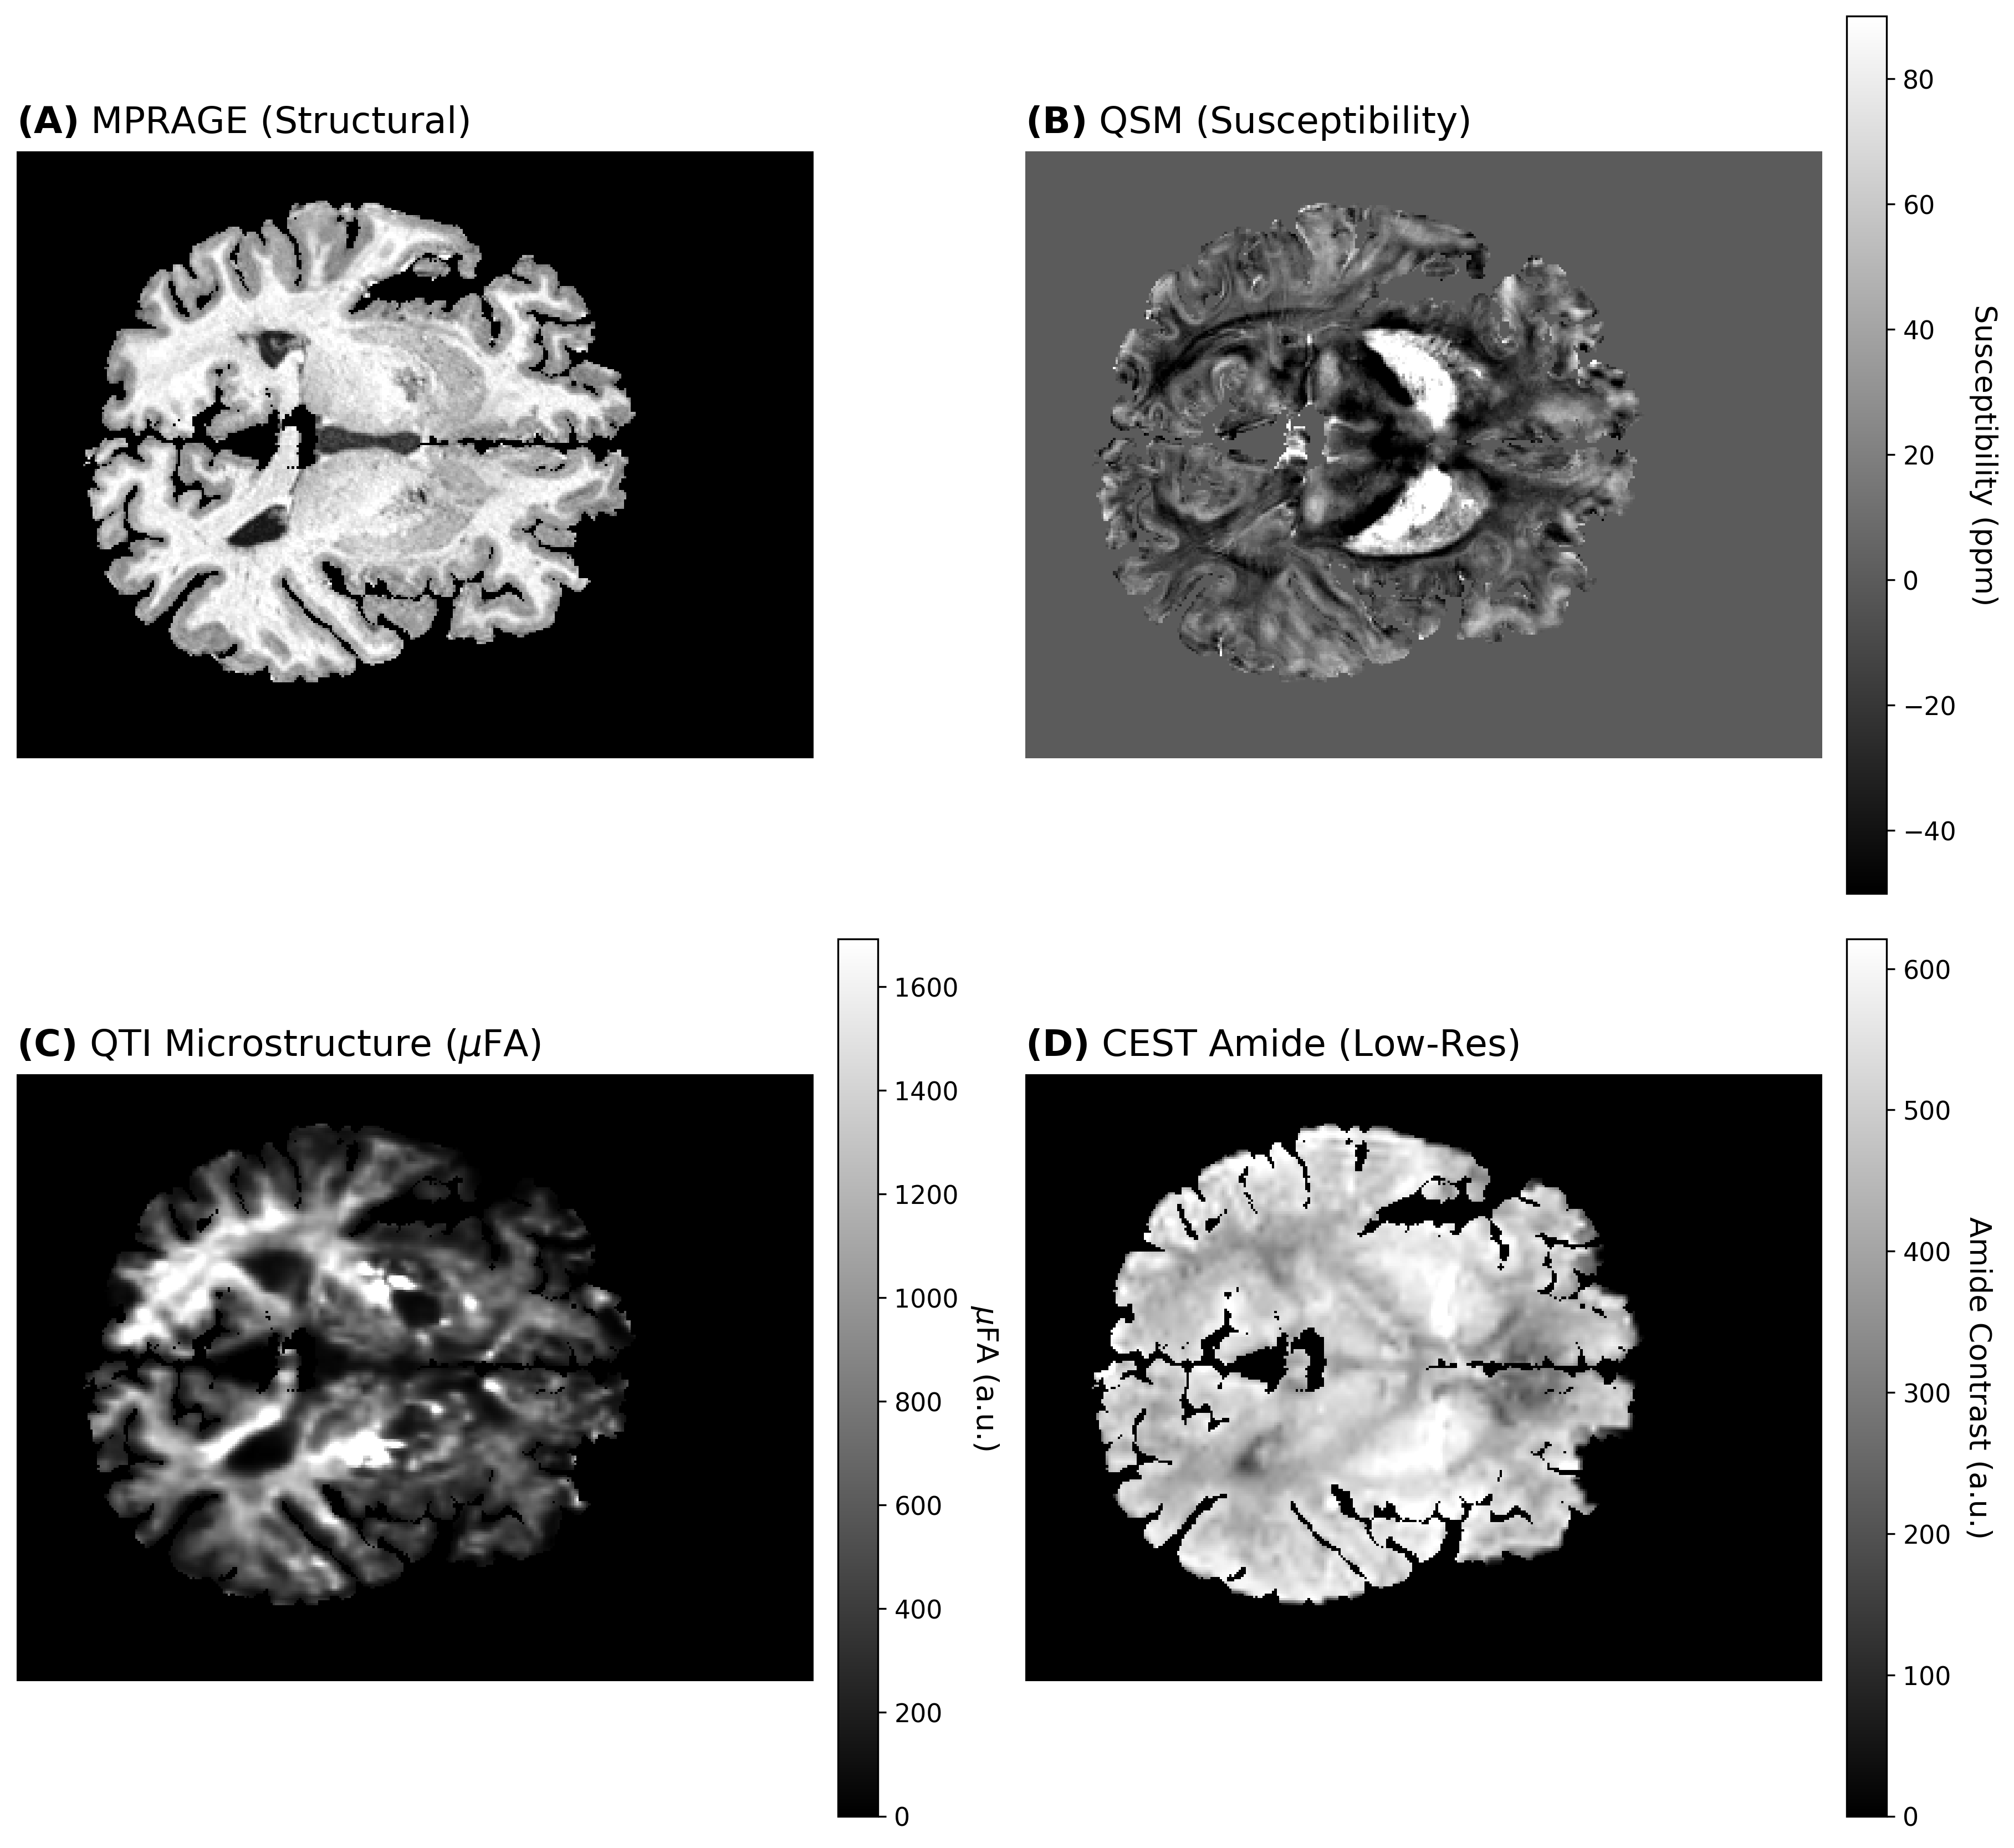

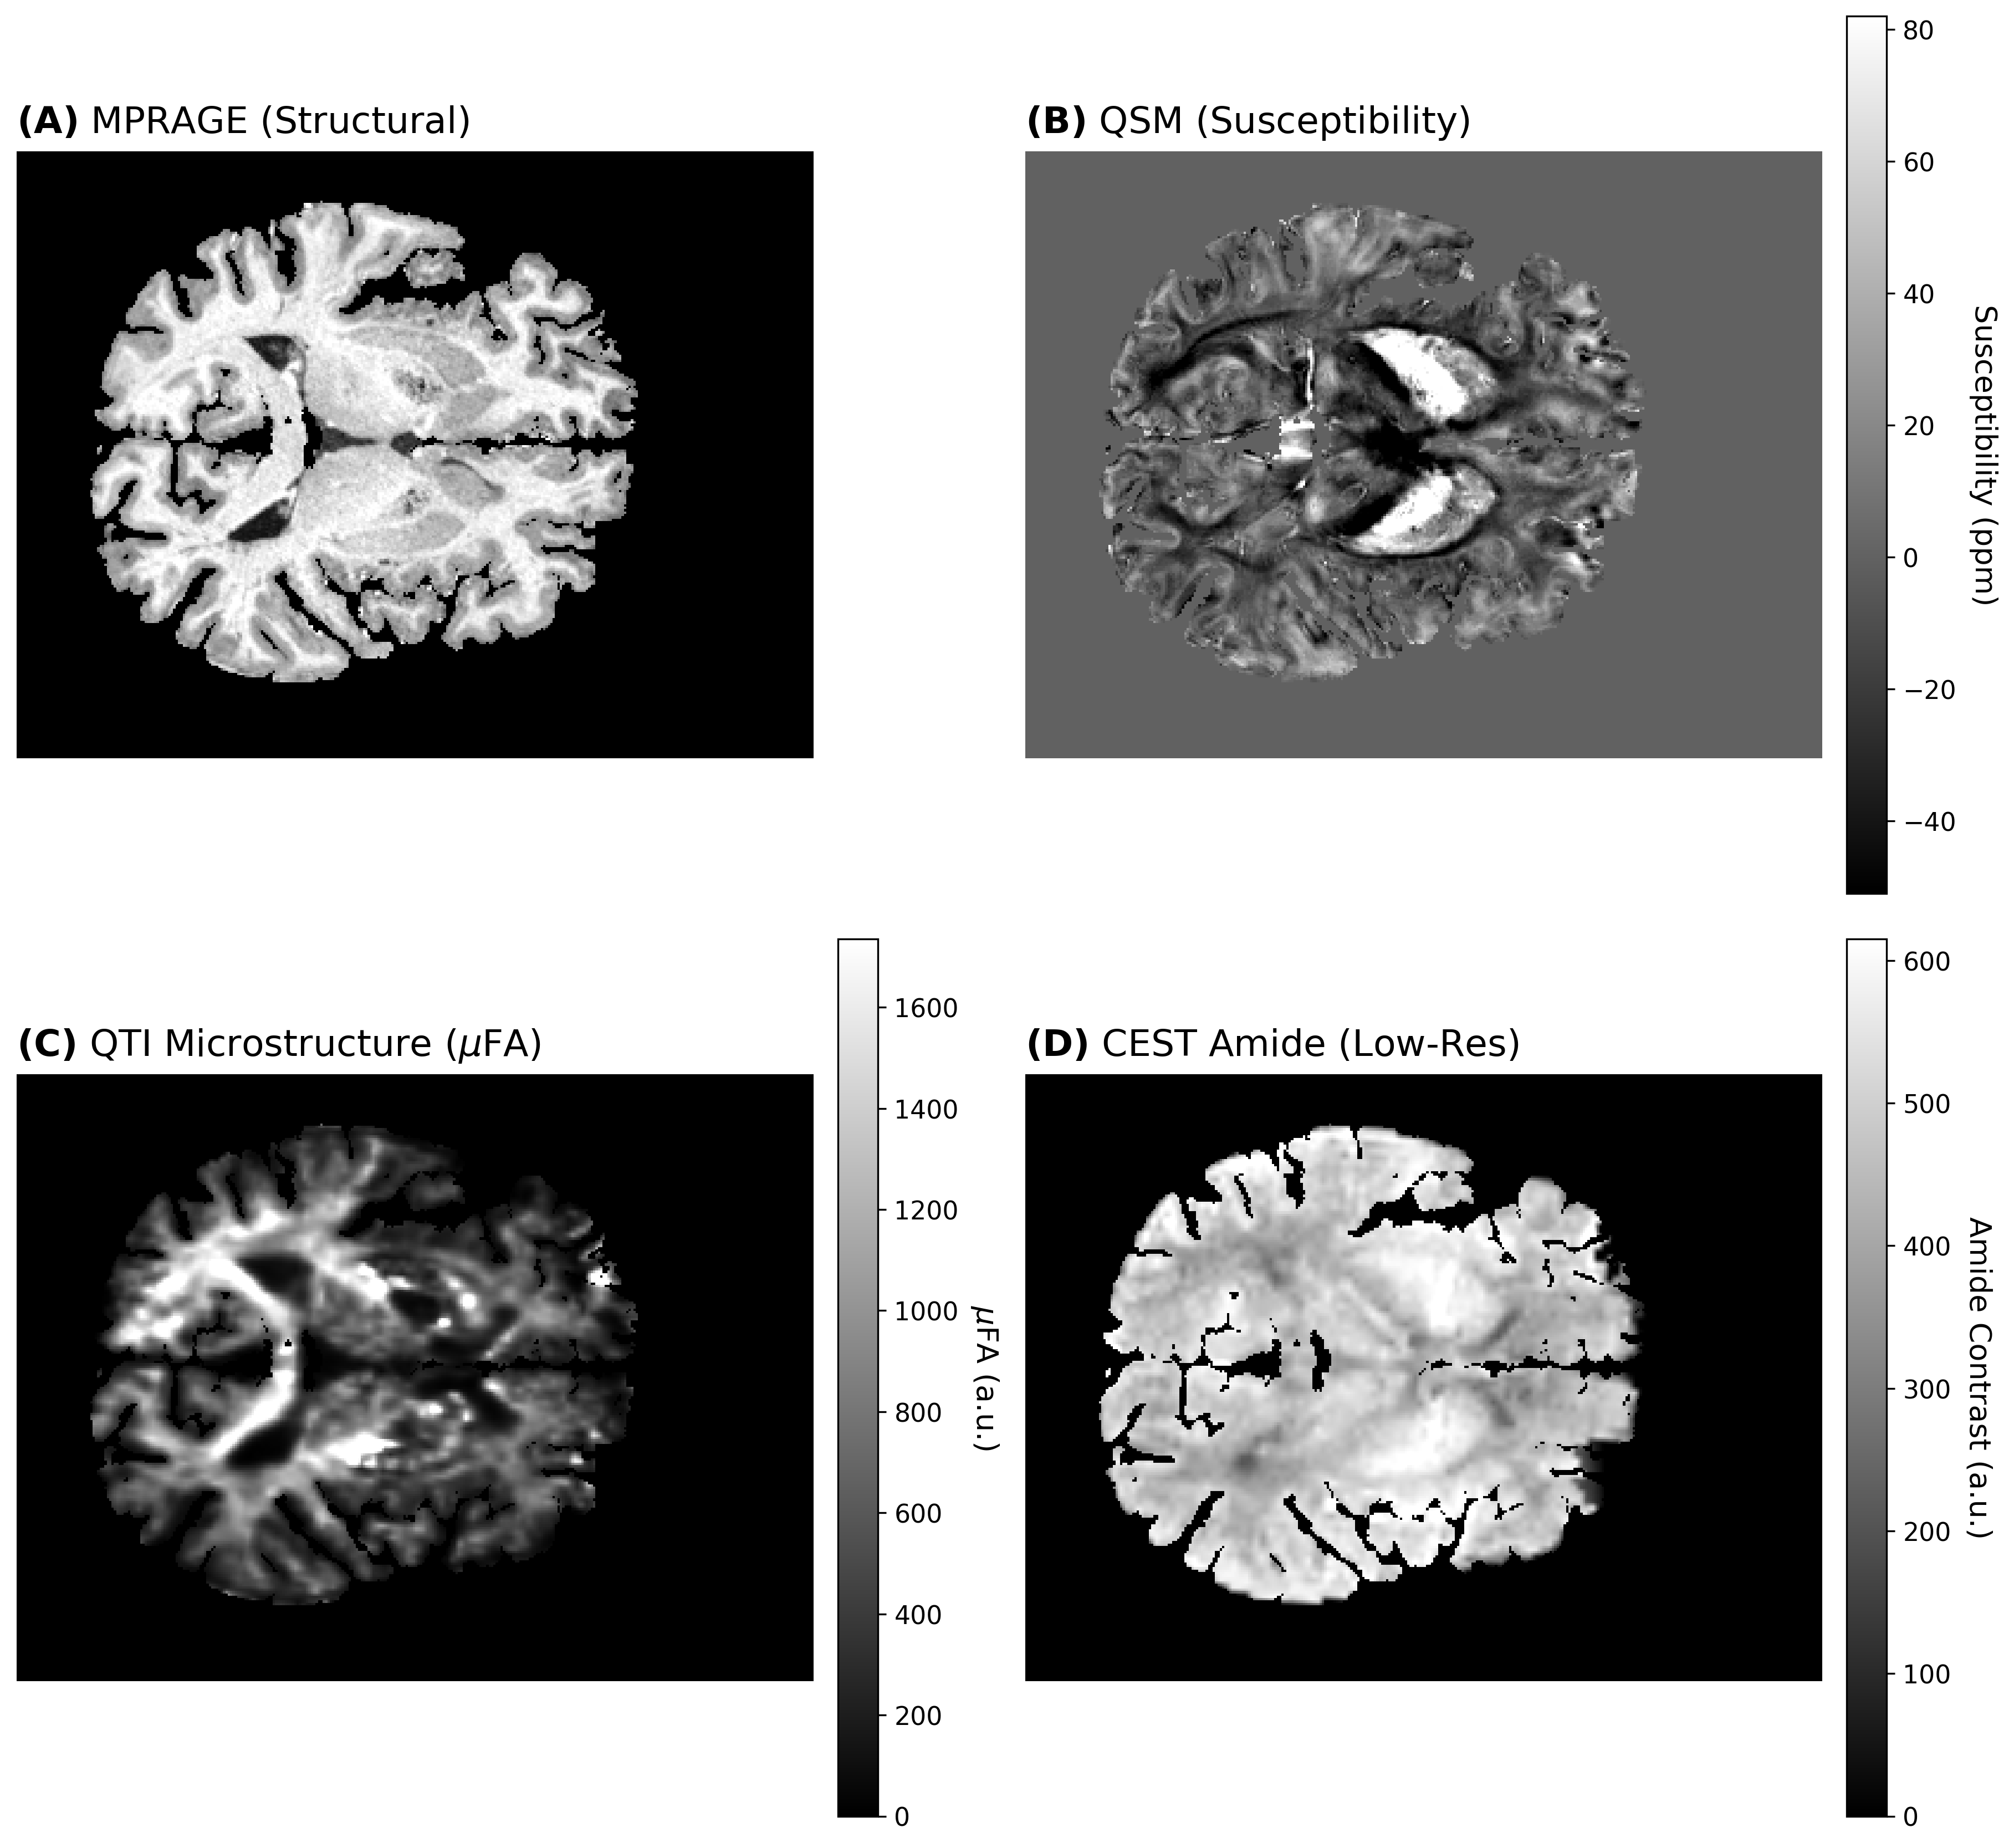

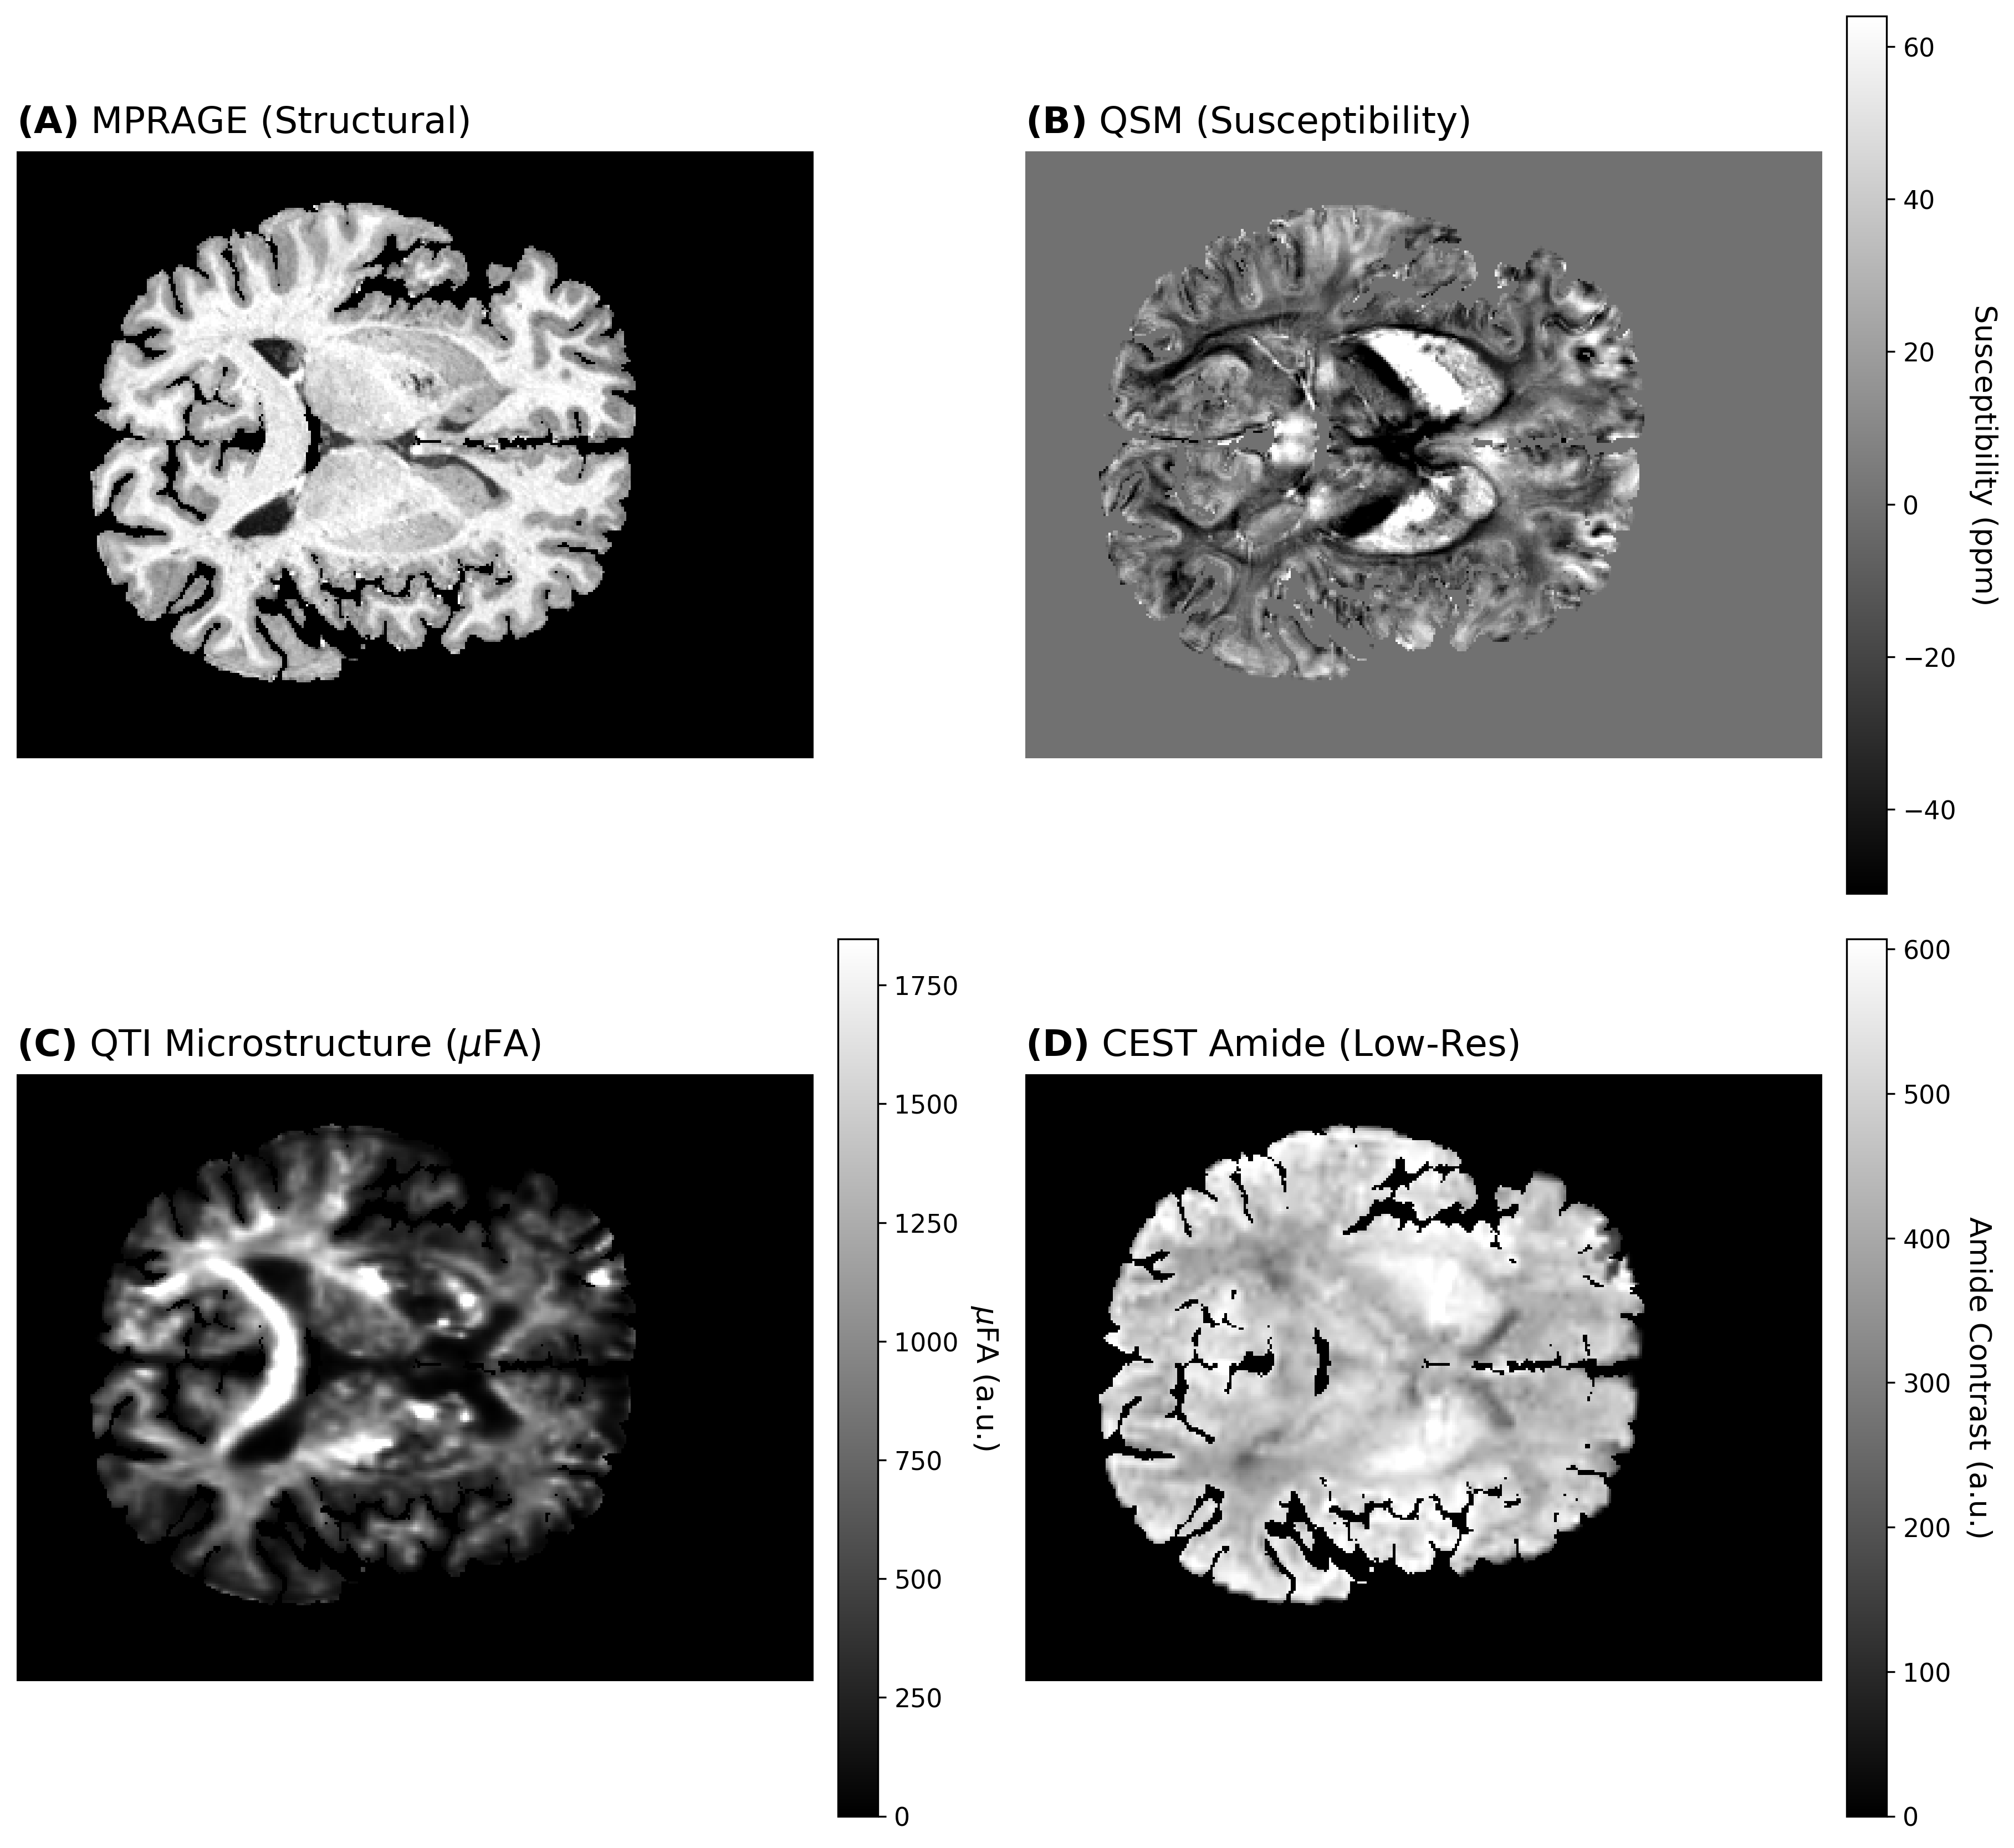

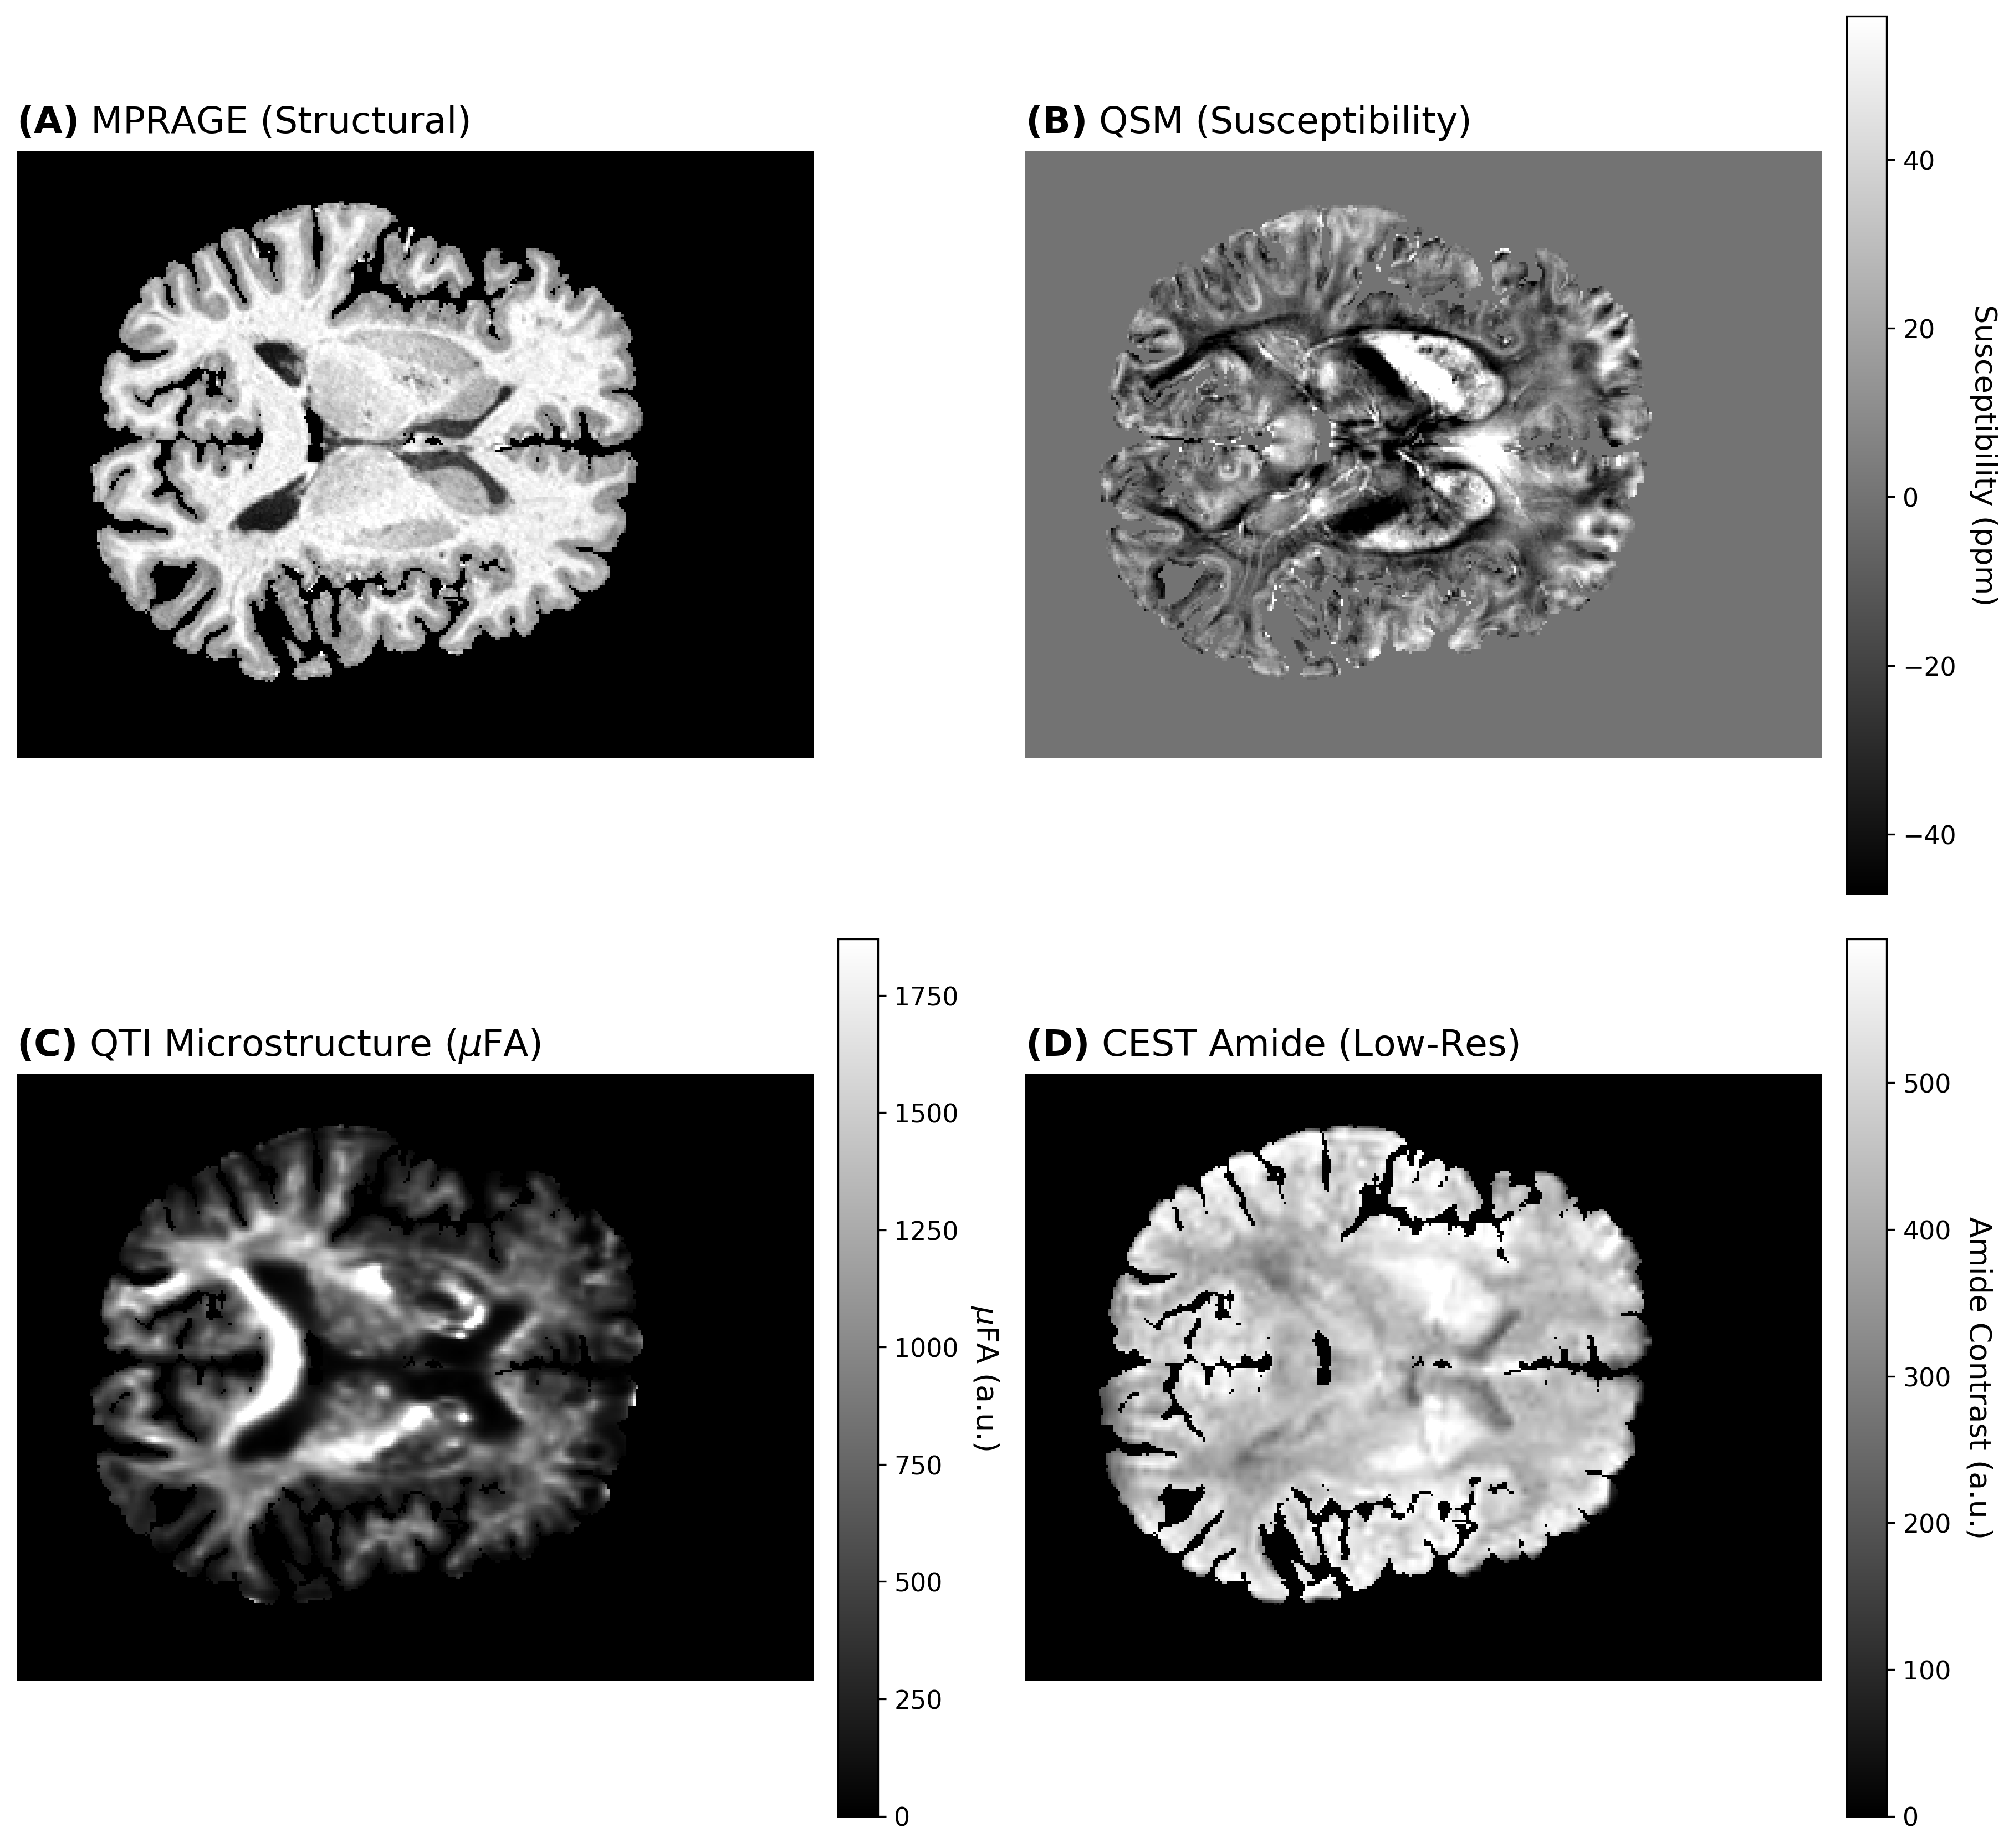

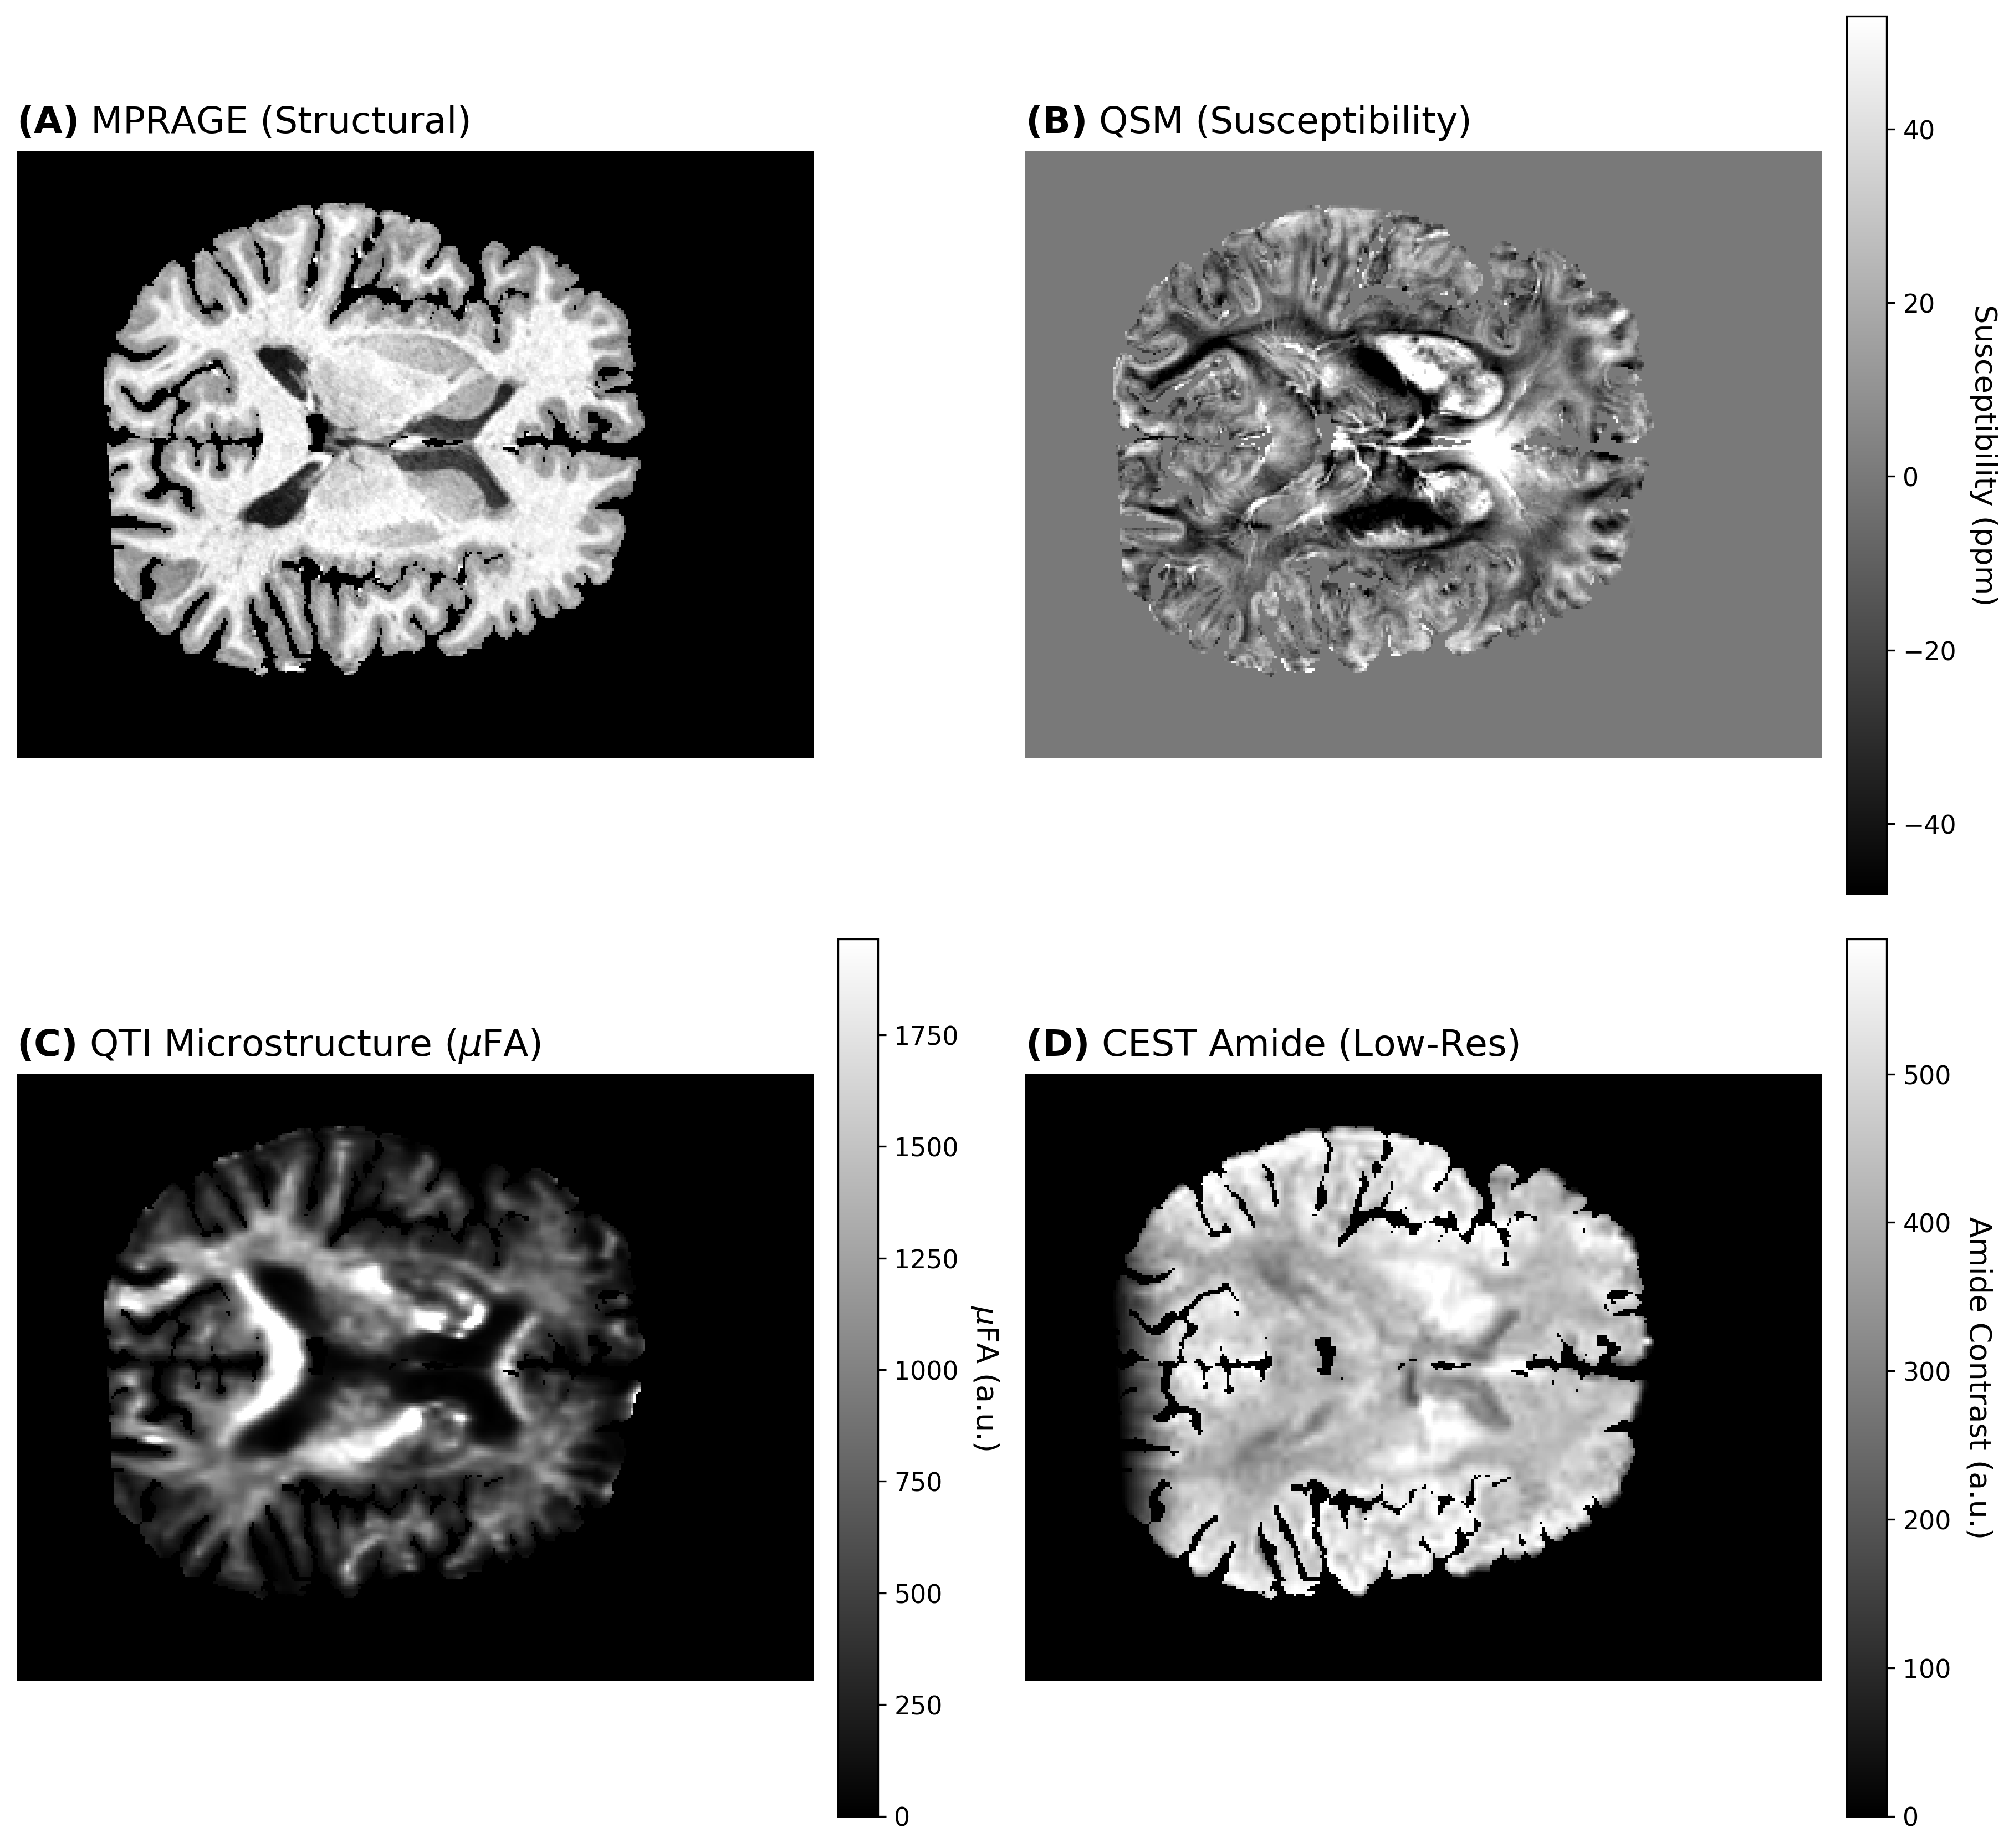

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# ================= 配置区域 =================
DATA_DIR = "/home/jovyan/gpu_space/workspace_jiayi/alex_datasets/3D_minimal"
LUT_PATH = "Freesurfer_LUT_alex_labels_jiayi.xlsx"

# 通道定义 (已修正：文档序号 - 1)
CH_UFA    = 14   # 文档第 15
CH_AMIDE  = 225  # 文档第 226
CH_MPRAGE = 341  # 文档第 342
CH_QSM    = 350  # 文档第 351 (最后一个)

# ================= 绘图参数 =================
TARGET_AXIS = 'Sagittal'
NUM_IMAGES  = 5
SLICE_STEP  = 3
TITLE_FS = 16
CBAR_FS  = 13
TICK_FS  = 11

def normalize_robust(img, p_low=1, p_high=99):
    if np.all(img == 0): return img
    vmin, vmax = np.percentile(img, [p_low, p_high])
    return np.clip(img, vmin, vmax)

def auto_find_best_range(labels_vol, axis, num_imgs, step):
    print(f"正在扫描 {axis} 方向的大脑截面大小...")
    if axis == 'Axial':     area = np.count_nonzero(labels_vol, axis=(0, 1))
    elif axis == 'Coronal': area = np.count_nonzero(labels_vol, axis=(0, 2))
    else:                   area = np.count_nonzero(labels_vol, axis=(1, 2))
    
    center_idx = int(np.argmax(area))
    start = max(0, center_idx - (num_imgs * step) // 2)
    end = start + num_imgs * step
    return list(range(start, end, step))[:num_imgs]

def get_slice_corrected(data, labels, axis, idx, k_rot):
    if axis == 'Axial':   d, l = data[:,:,idx,:], labels[:,:,idx]
    elif axis == 'Coronal': d, l = data[:,idx,:,:], labels[:,idx,:]
    else:                 d, l = data[idx,:,:,:], labels[idx,:,:]
    return np.rot90(d, k=k_rot), np.rot90(l, k=k_rot)

def plot_contrasts_2x2(img_mprage, img_qsm, img_ufa, img_amide,
                       title_fs=16, cbar_fs=13, tick_fs=11):
    fig = plt.figure(figsize=(12, 11), dpi=300, constrained_layout=True)
    gs = fig.add_gridspec(2, 4, width_ratios=[1, 0.05, 1, 0.05], wspace=0.05, hspace=0.05)

    # Row 1
    axA = fig.add_subplot(gs[0,0]); caxA = fig.add_subplot(gs[0,1])
    axB = fig.add_subplot(gs[0,2]); caxB = fig.add_subplot(gs[0,3])
    # Row 2
    axC = fig.add_subplot(gs[1,0]); caxC = fig.add_subplot(gs[1,1])
    axD = fig.add_subplot(gs[1,2]); caxD = fig.add_subplot(gs[1,3])

    # A: MPRAGE
    axA.imshow(normalize_robust(img_mprage), cmap='gray', aspect='equal')
    axA.set_title(r"$\bf{(A)}$ MPRAGE (Structural)", loc='left', fontsize=title_fs, pad=8)
    axA.axis('off'); caxA.axis('off')

    # B: QSM
    imB = axB.imshow(normalize_robust(img_qsm), cmap='gray', aspect='equal')
    axB.set_title(r"$\bf{(B)}$ QSM (Susceptibility)", loc='left', fontsize=title_fs, pad=8)
    axB.axis('off')
    cbB = fig.colorbar(imB, cax=caxB)
    cbB.set_label("Susceptibility (ppm)", rotation=270, labelpad=18, fontsize=cbar_fs)
    cbB.ax.tick_params(labelsize=tick_fs)

    # C: QTI
    imC = axC.imshow(normalize_robust(img_ufa), cmap='gray', aspect='equal')
    axC.set_title(r"$\bf{(C)}$ QTI Microstructure ($\mu$FA)", loc='left', fontsize=title_fs, pad=8)
    axC.axis('off')
    cbC = fig.colorbar(imC, cax=caxC)
    cbC.set_label("$\mu$FA (a.u.)", rotation=270, labelpad=18, fontsize=cbar_fs)
    cbC.ax.tick_params(labelsize=tick_fs)

    # D: CEST
    imD = axD.imshow(normalize_robust(img_amide), cmap='gray', aspect='equal', interpolation='nearest')
    axD.set_title(r"$\bf{(D)}$ CEST Amide (Low-Res)", loc='left', fontsize=title_fs, pad=8)
    axD.axis('off')
    cbD = fig.colorbar(imD, cax=caxD)
    cbD.set_label("Amide Contrast (a.u.)", rotation=270, labelpad=18, fontsize=cbar_fs)
    cbD.ax.tick_params(labelsize=tick_fs)
    import matplotlib.patches as patches

    def add_marker(ax, xy, diameter_px, color='red', lw=2):
        # 注意：imshow 默认坐标系是 (x=列, y=行)
        x, y = xy
        r = diameter_px / 2.0
        circ = patches.Circle((x, y), radius=r, fill=False, edgecolor=color, linewidth=lw)
        ax.add_patch(circ)
    
    for ax in [axA, axB, axC, axD]:
        add_marker(ax, marker_xy, marker_diameter_px, marker_color, marker_lw)

    plt.show()

# ================= 主程序 =================
mat_files = sorted(list(Path(DATA_DIR).glob("*.mat")))
if not mat_files: raise FileNotFoundError("未找到数据文件")

target_file = mat_files[0]
print(f"📂 加载数据: {target_file.name}")

with h5py.File(target_file, "r") as f:
    raw_data = f["data"][:]
    data_vol = np.moveaxis(raw_data, 0, -1)
    
    # ----------------------------------------------------
    # 🔥 关键检查：验证通道数
    # ----------------------------------------------------
    n_channels = data_vol.shape[-1]
    print(f"✅ 数据加载完成。维度: {data_vol.shape}")
    print(f"✅ 总通道数: {n_channels}")
    
    if n_channels == 351:
        print("✅ 验证通过：通道数与描述 (351) 完全一致！")
        print("   -> Index 350 是最后一个通道 (QSM)，配置正确。")
    else:
        print(f"⚠️ 警告：数据通道数是 {n_channels}，而描述是 351。请再次检查维度！")

    labels_vol = f["region_labels"][:]
    if labels_vol.ndim == 4:
        if labels_vol.shape[0] == 1: labels_vol = labels_vol[0]
        else: labels_vol = np.moveaxis(labels_vol, 0, -1)

# 绘图
target_slices = auto_find_best_range(labels_vol, TARGET_AXIS, NUM_IMAGES, SLICE_STEP)
for slice_idx in target_slices:
    try:
        sl_data, _ = get_slice_corrected(data_vol, labels_vol, TARGET_AXIS, slice_idx, ROTATION_K)
        # 这里使用了修正后的 0-based 索引
        plot_contrasts_2x2(
            sl_data[..., CH_MPRAGE], 
            sl_data[..., CH_QSM], 
            sl_data[..., CH_UFA], 
            sl_data[..., CH_AMIDE],
            title_fs=TITLE_FS, cbar_fs=CBAR_FS, tick_fs=TICK_FS
        )
    except IndexError as e:
        print(f"❌ 索引错误 (层 {slice_idx}): {e}")

In [22]:

import matplotlib.patches as patches

def plot_contrasts_2x2(img_mprage, img_qsm, img_ufa, img_amide,
                       title_fs=16, cbar_fs=13, tick_fs=11,
                       marker_xy=None, marker_diameter_px=800,
                       marker_color='red', marker_lw=3):

    fig = plt.figure(figsize=(12, 11), dpi=300, constrained_layout=True)
    gs = fig.add_gridspec(2, 4, width_ratios=[1, 0.05, 1, 0.05], wspace=0.05, hspace=0.05)

    # Row 1
    axA = fig.add_subplot(gs[0,0]); caxA = fig.add_subplot(gs[0,1])
    axB = fig.add_subplot(gs[0,2]); caxB = fig.add_subplot(gs[0,3])
    # Row 2
    axC = fig.add_subplot(gs[1,0]); caxC = fig.add_subplot(gs[1,1])
    axD = fig.add_subplot(gs[1,2]); caxD = fig.add_subplot(gs[1,3])

    # A: MPRAGE
    axA.imshow(normalize_robust(img_mprage), cmap='gray', aspect='equal')
    axA.set_title(r"$\bf{(A)}$ MPRAGE (Structural)", loc='left', fontsize=title_fs, pad=8)
    axA.axis('off'); caxA.axis('off')

    # B: QSM
    imB = axB.imshow(normalize_robust(img_qsm), cmap='gray', aspect='equal')
    axB.set_title(r"$\bf{(B)}$ QSM (Susceptibility)", loc='left', fontsize=title_fs, pad=8)
    axB.axis('off')
    cbB = fig.colorbar(imB, cax=caxB)
    cbB.set_label("Susceptibility (ppm)", rotation=270, labelpad=18, fontsize=cbar_fs)
    cbB.ax.tick_params(labelsize=tick_fs)

    # C: QTI
    imC = axC.imshow(normalize_robust(img_ufa), cmap='gray', aspect='equal')
    axC.set_title(r"$\bf{(C)}$ QTI Microstructure ($\mu$FA)", loc='left', fontsize=title_fs, pad=8)
    axC.axis('off')
    cbC = fig.colorbar(imC, cax=caxC)
    cbC.set_label("$\mu$FA (a.u.)", rotation=270, labelpad=18, fontsize=cbar_fs)
    cbC.ax.tick_params(labelsize=tick_fs)

    # D: CEST
    imD = axD.imshow(normalize_robust(img_amide), cmap='gray', aspect='equal', interpolation='nearest')
    axD.set_title(r"$\bf{(D)}$ CEST Amide (Low-Res)", loc='left', fontsize=title_fs, pad=8)
    axD.axis('off')
    cbD = fig.colorbar(imD, cax=caxD)
    cbD.set_label("Amide Contrast (a.u.)", rotation=270, labelpad=18, fontsize=cbar_fs)
    cbD.ax.tick_params(labelsize=tick_fs)
    import matplotlib.patches as patches
    def add_marker(ax, xy, size=80, color='red'):
        x, y = xy
        ax.scatter([x], [y], s=size, c=color)
    
    for ax in [axA, axB, axC, axD]:
        add_marker(ax, marker_xy, size=120)

    plt.show()

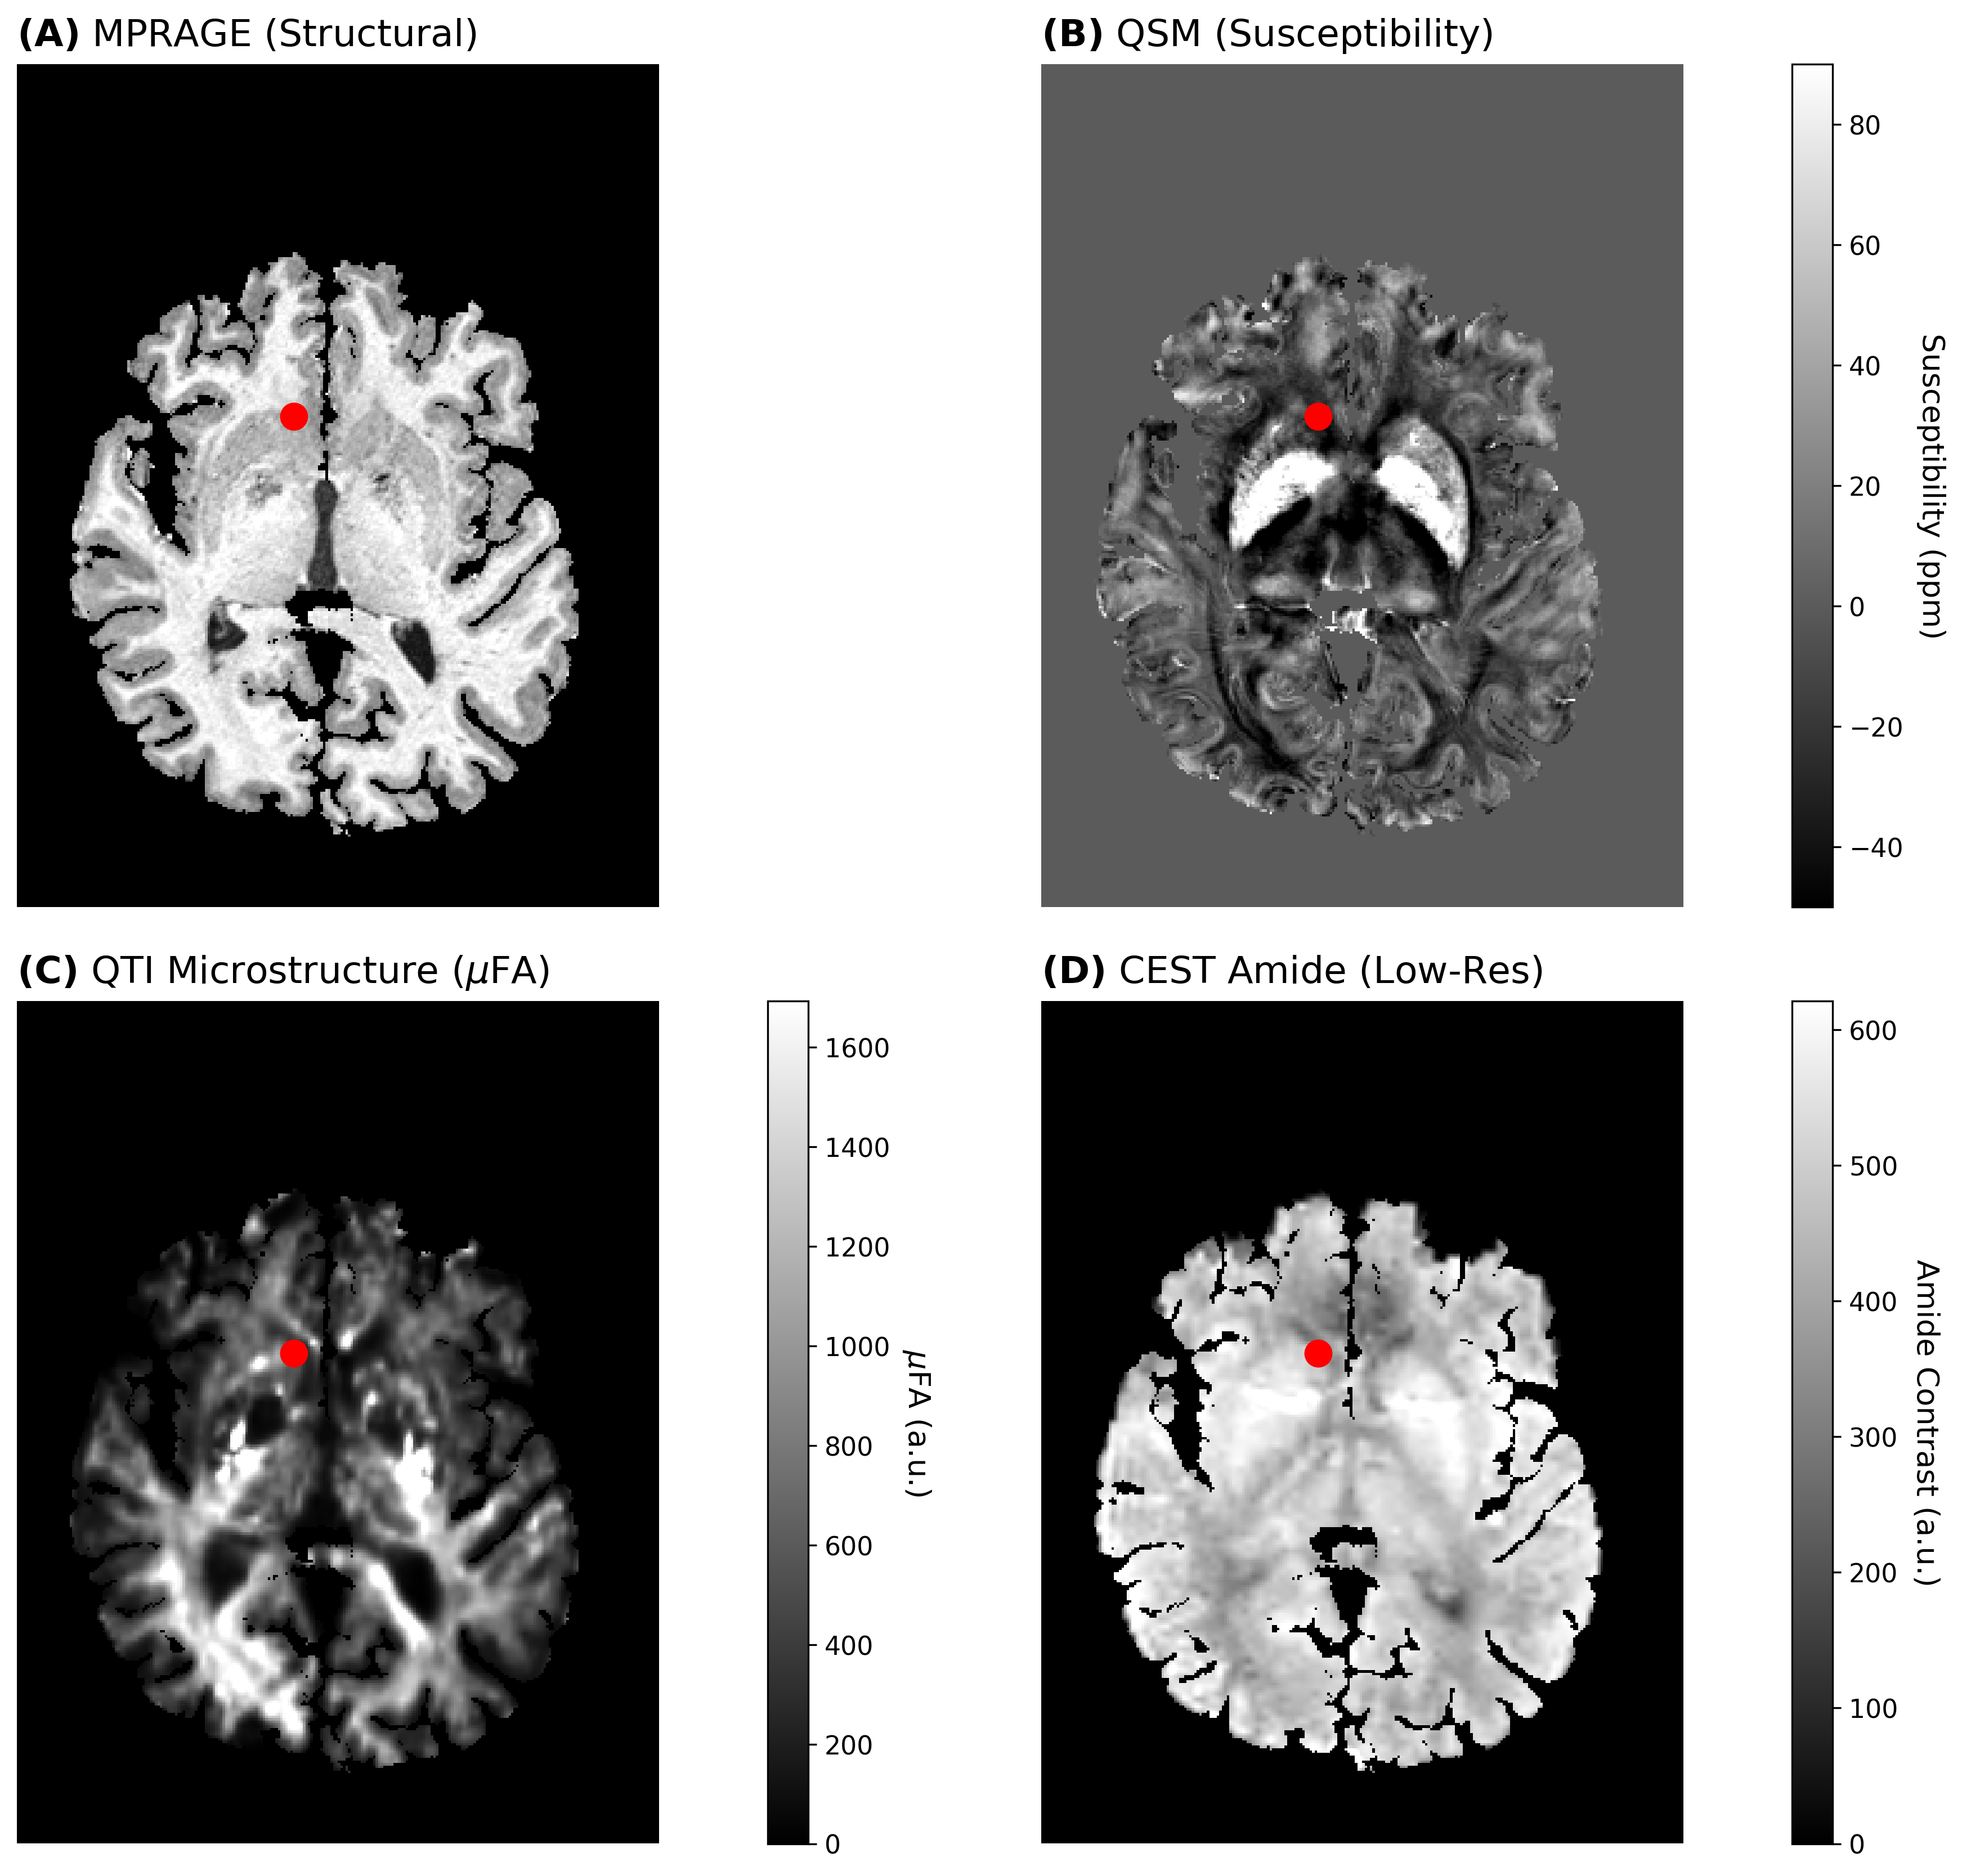

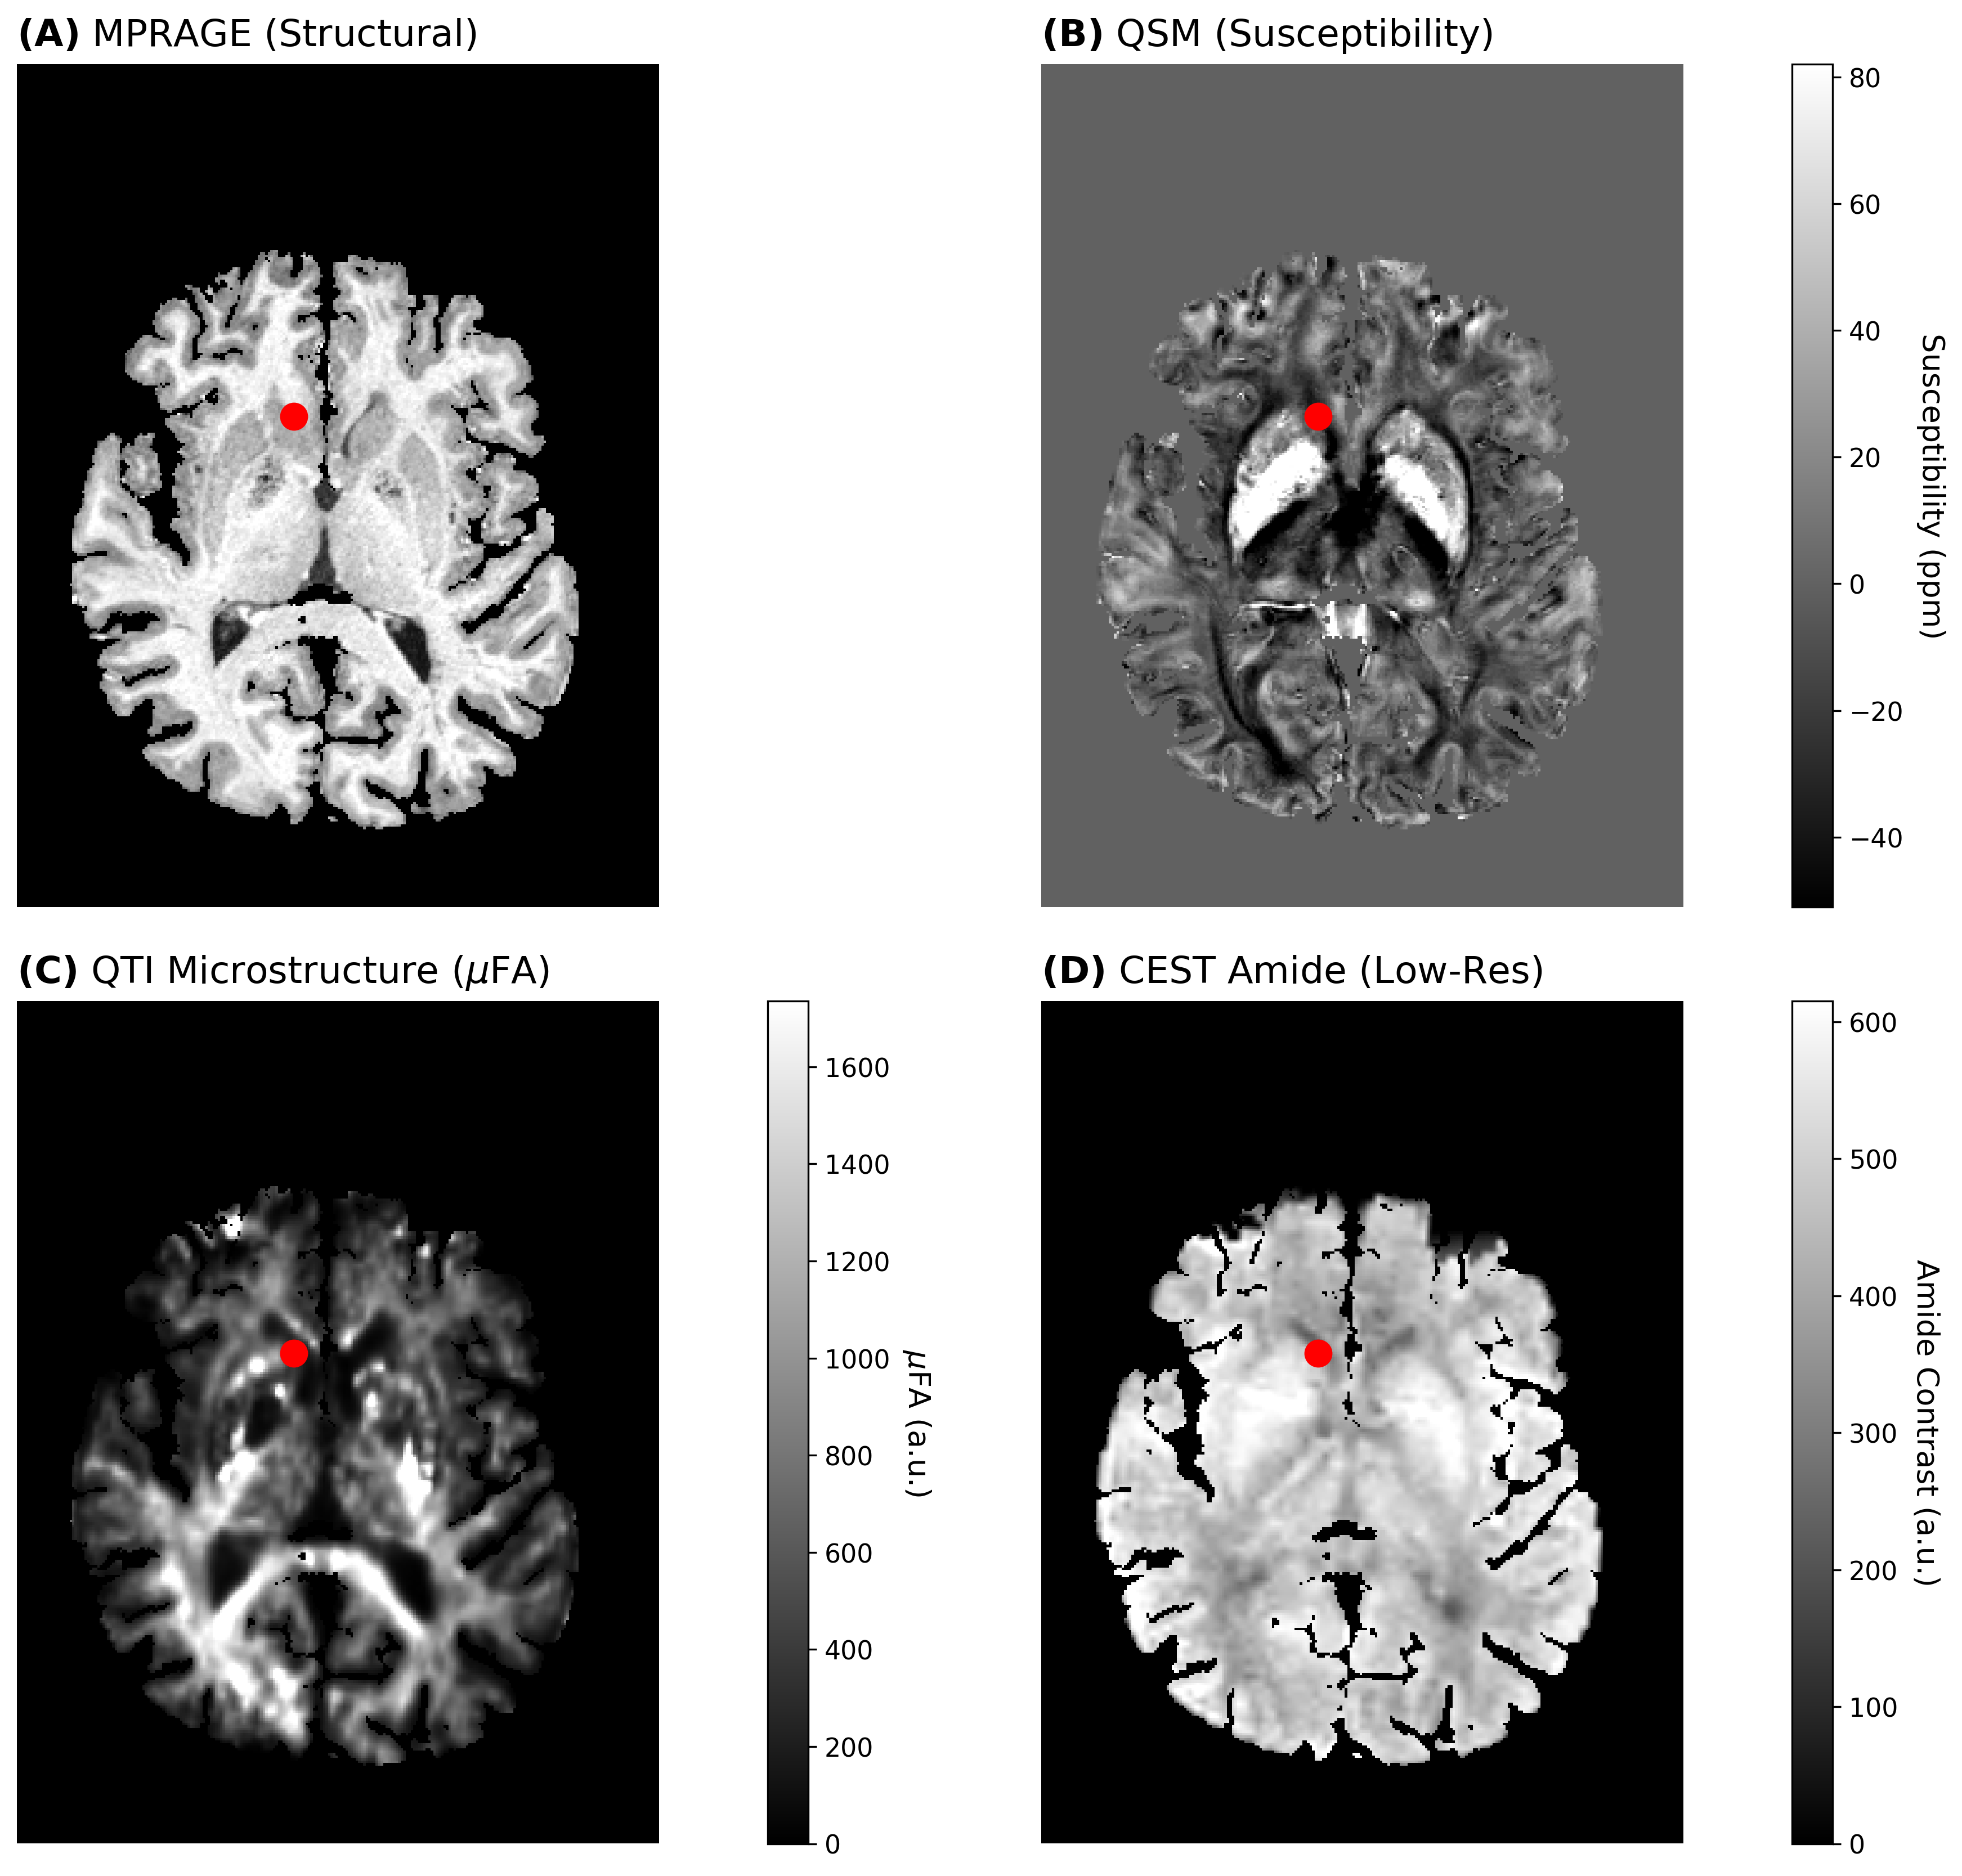

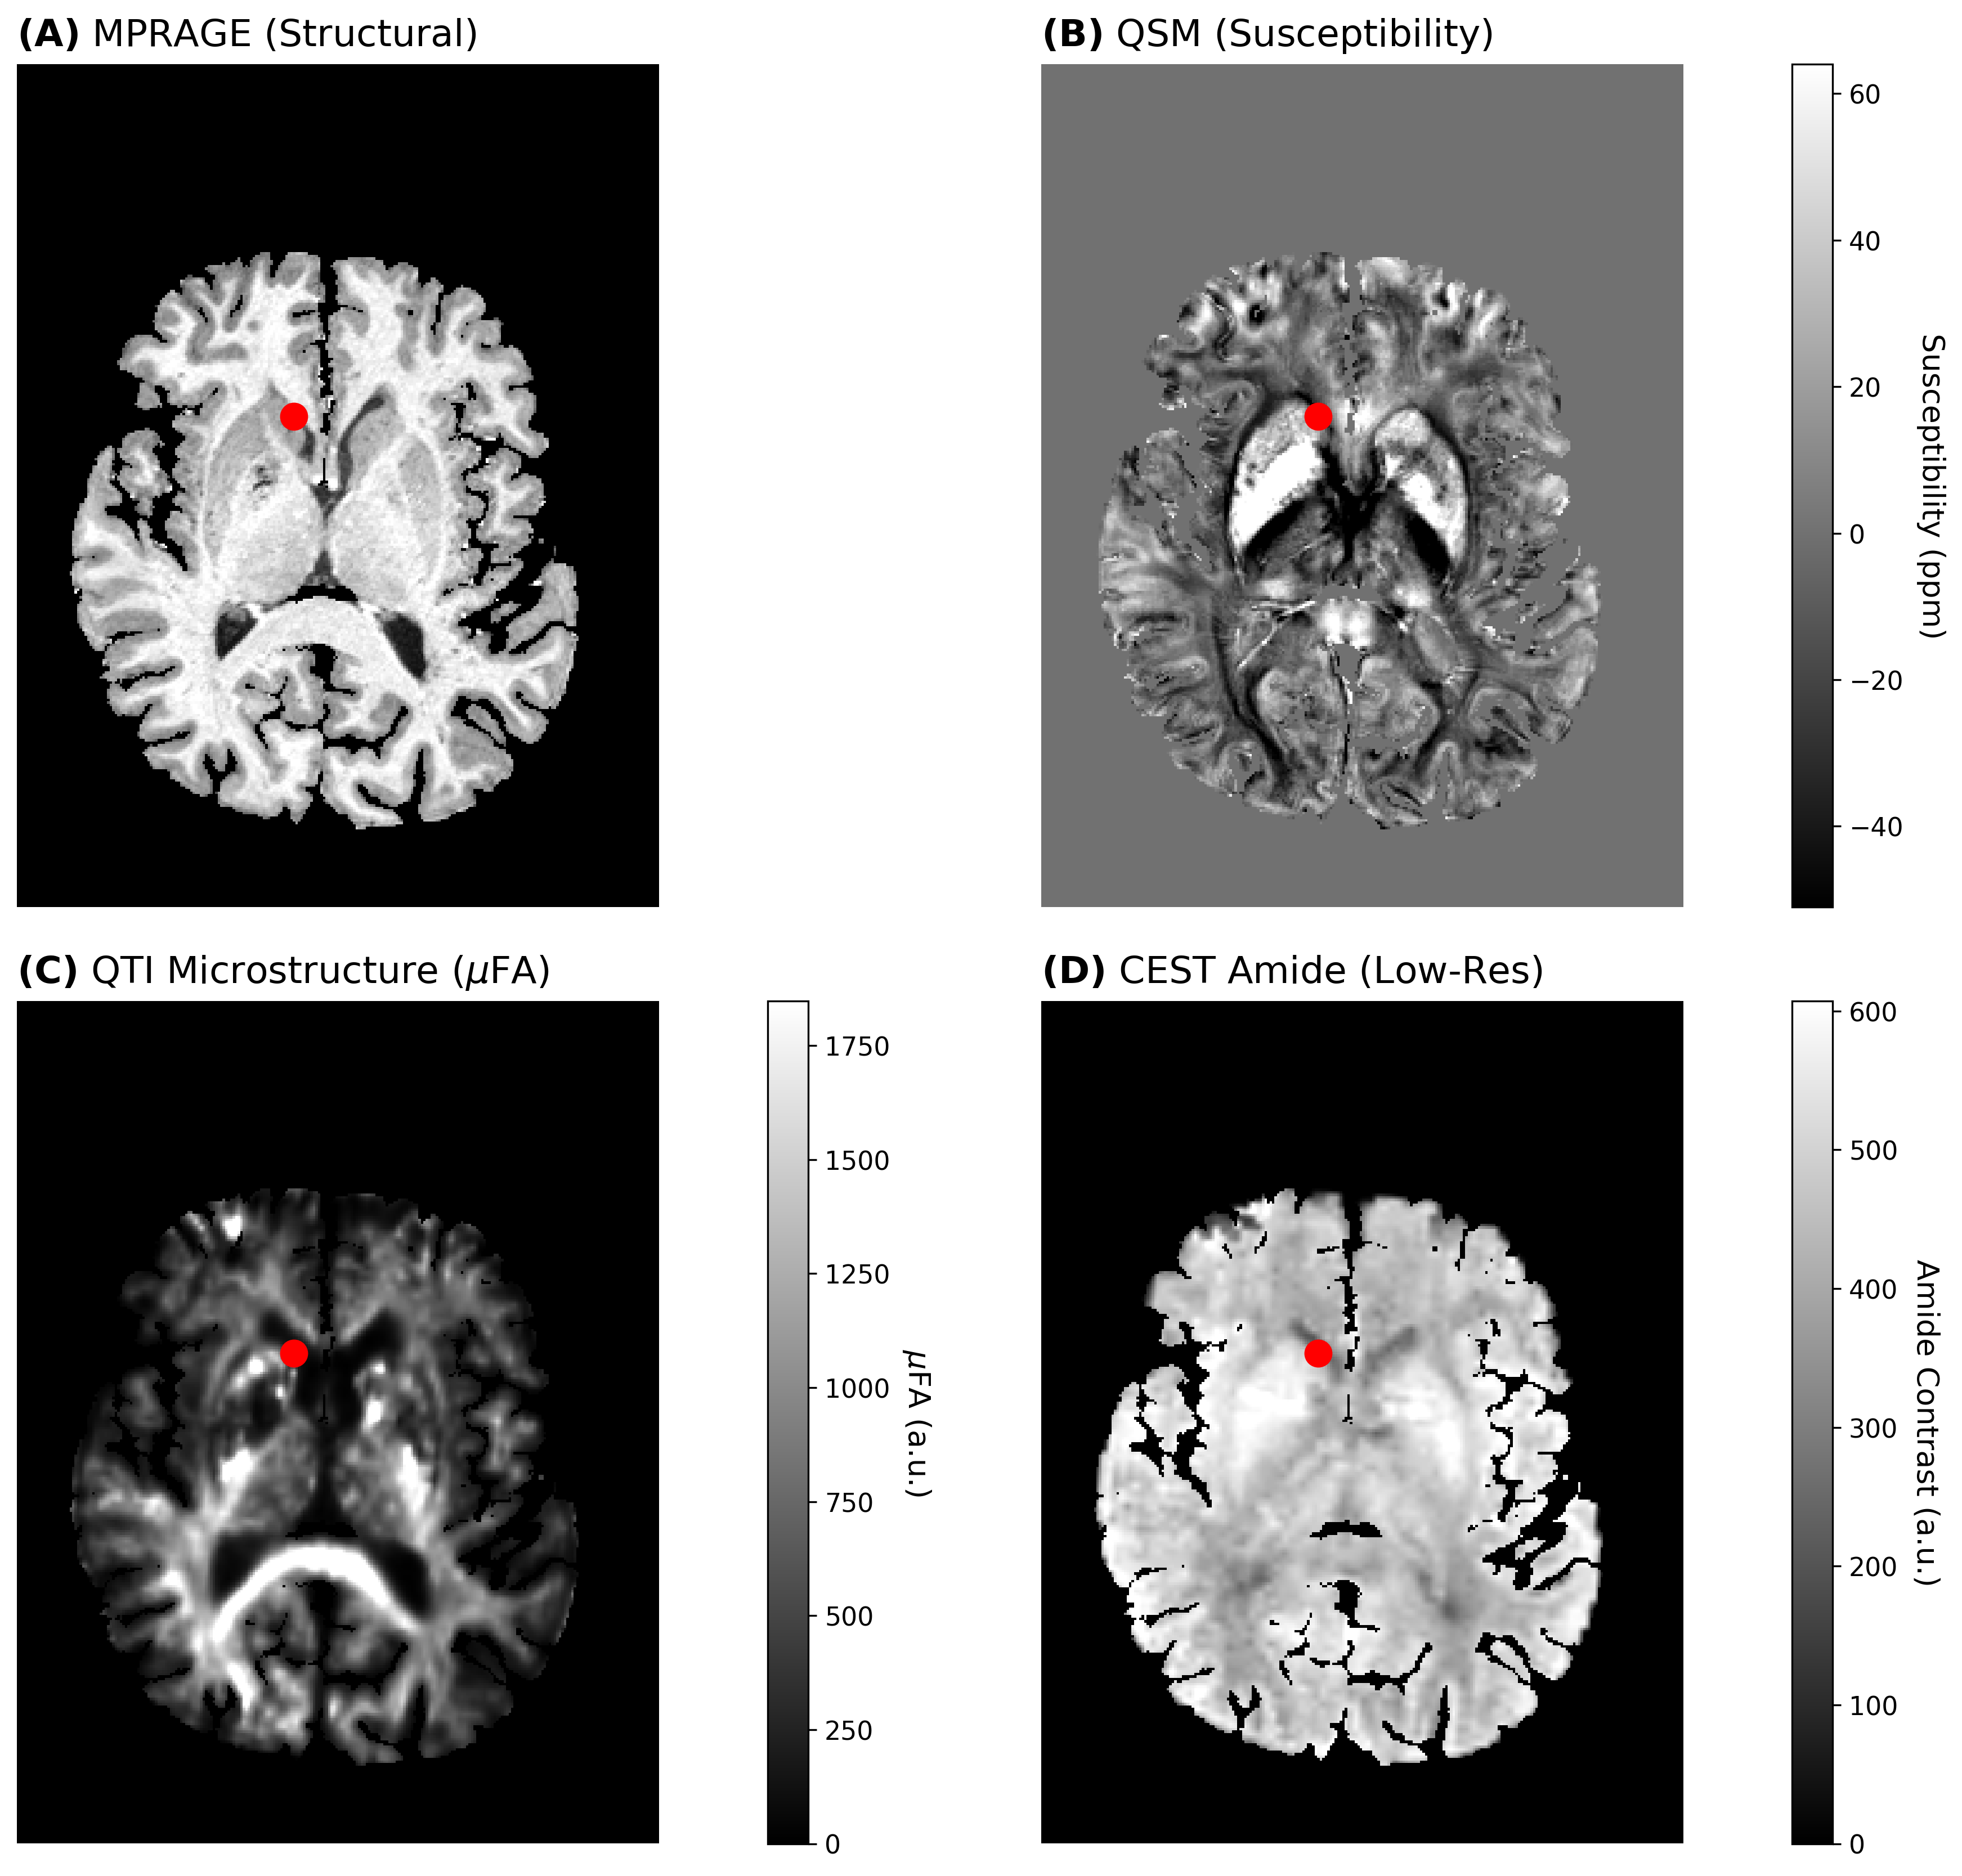

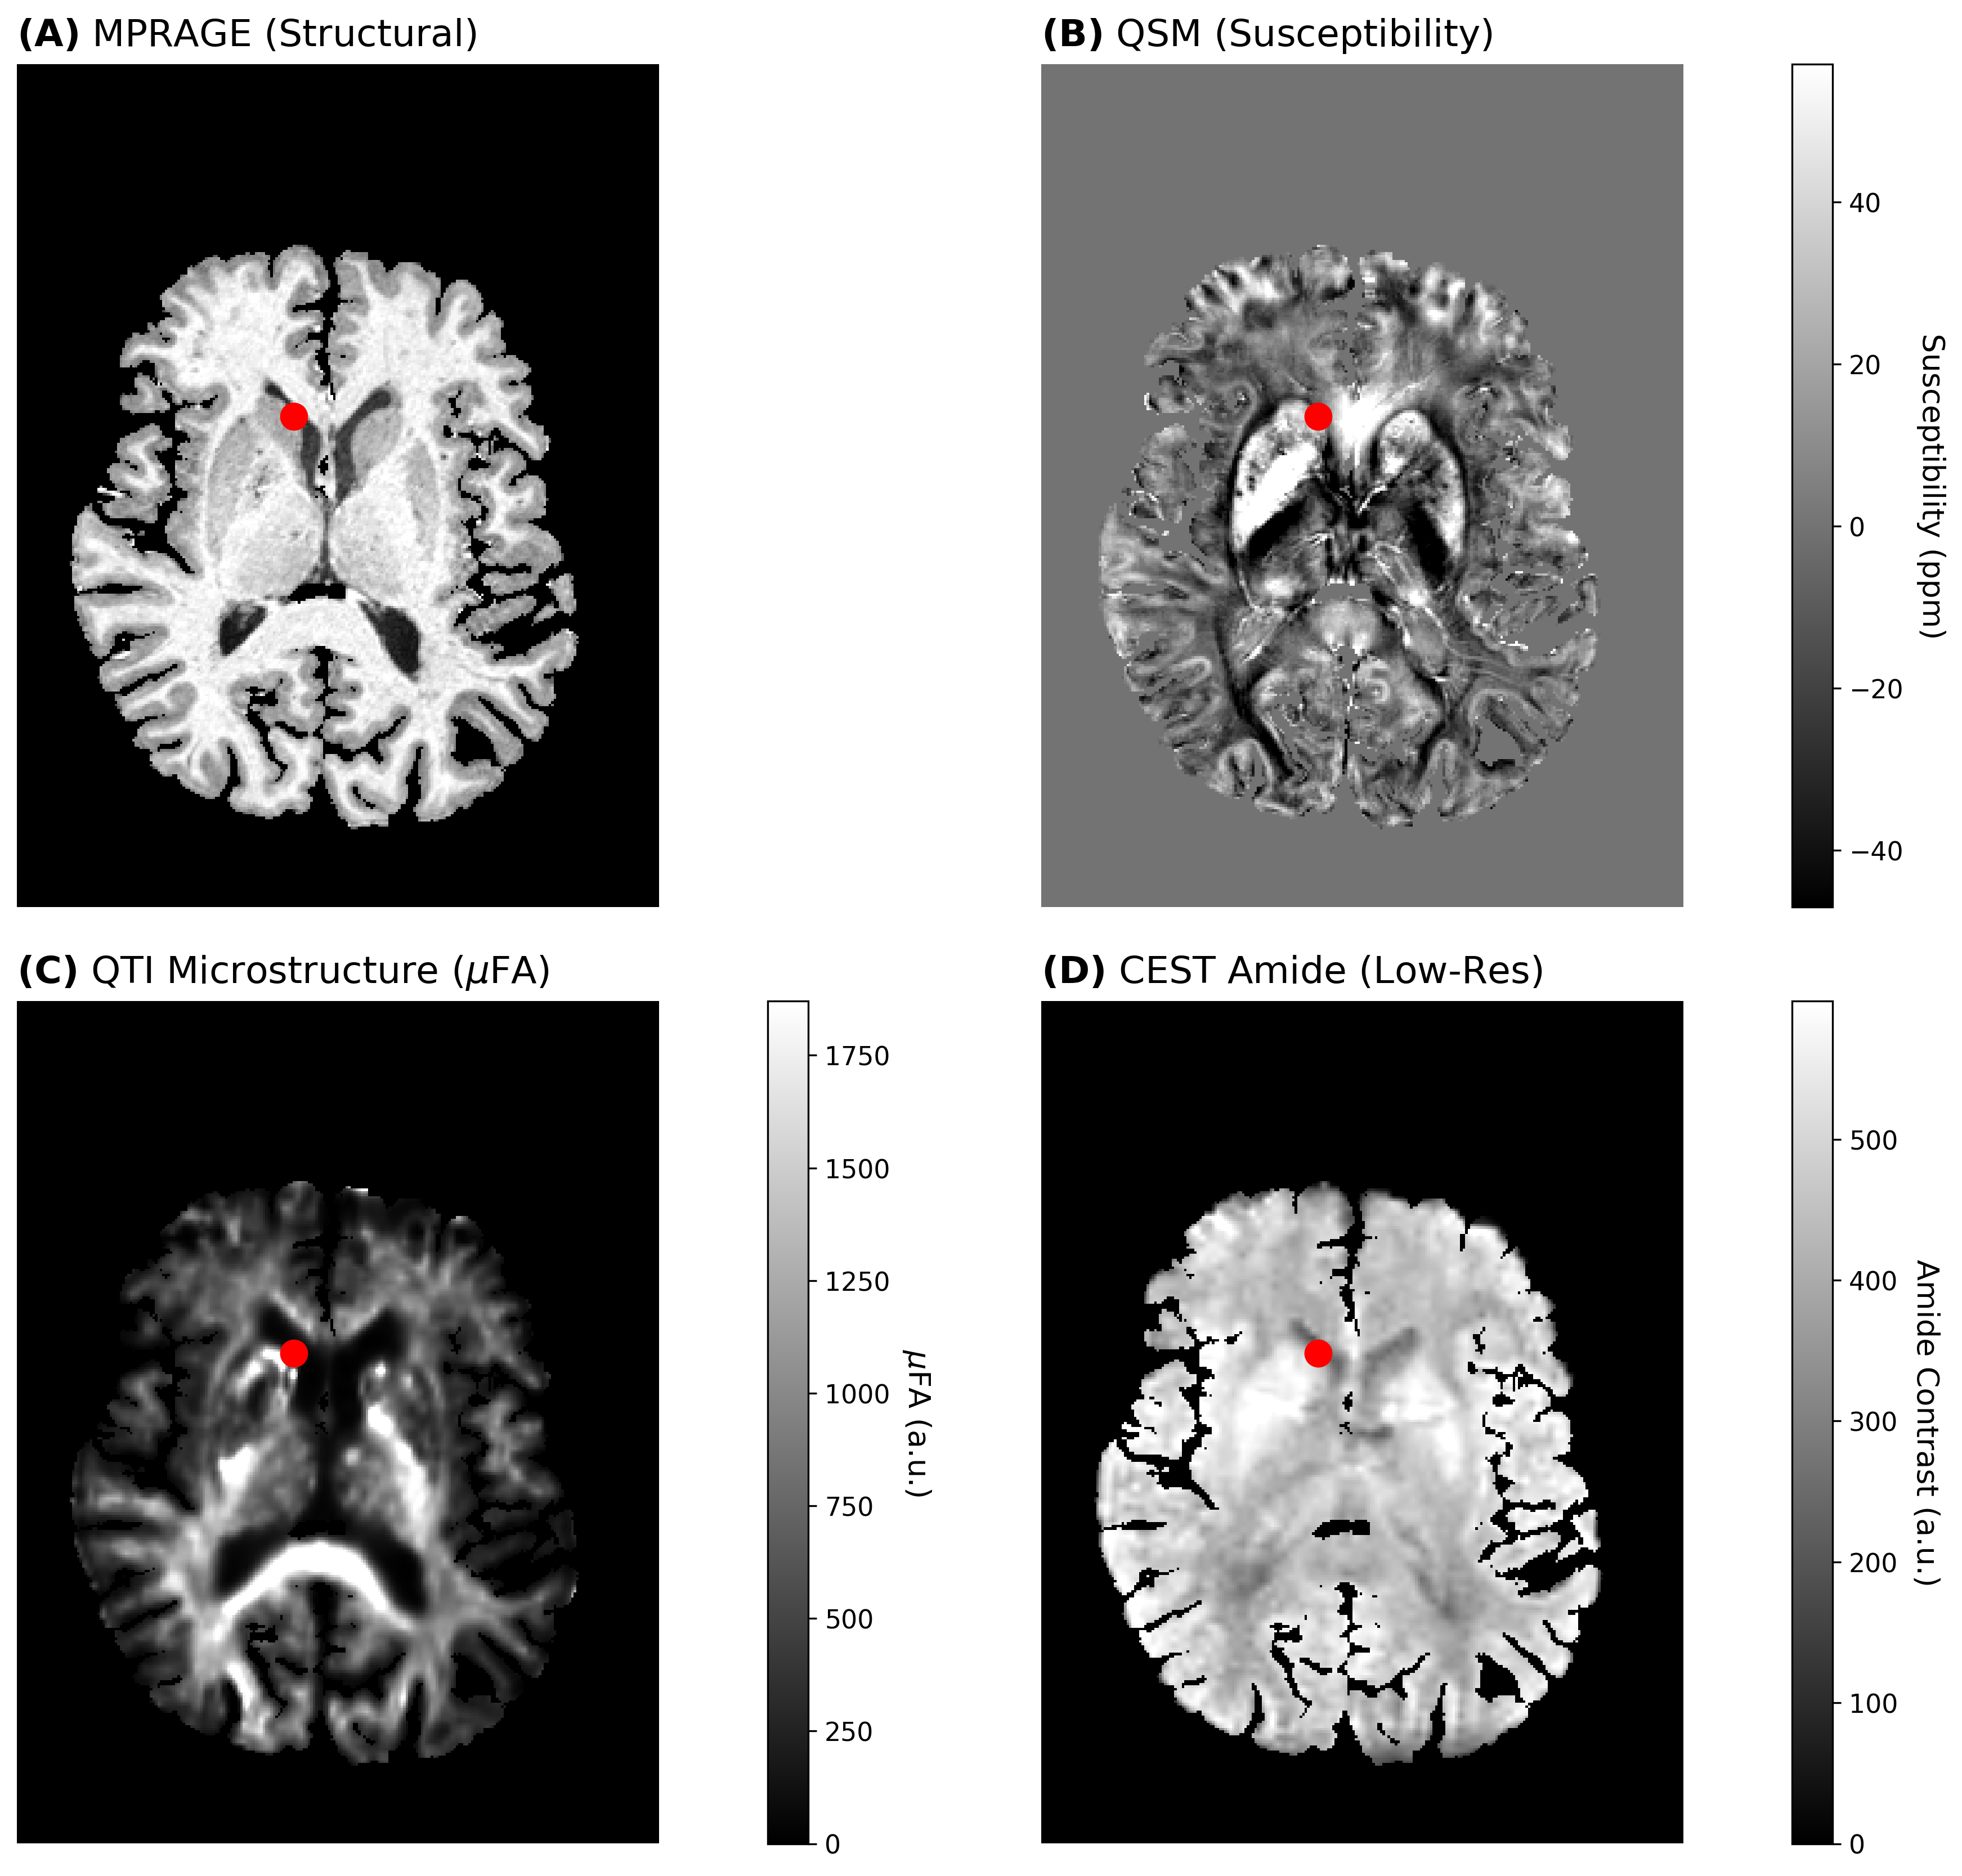

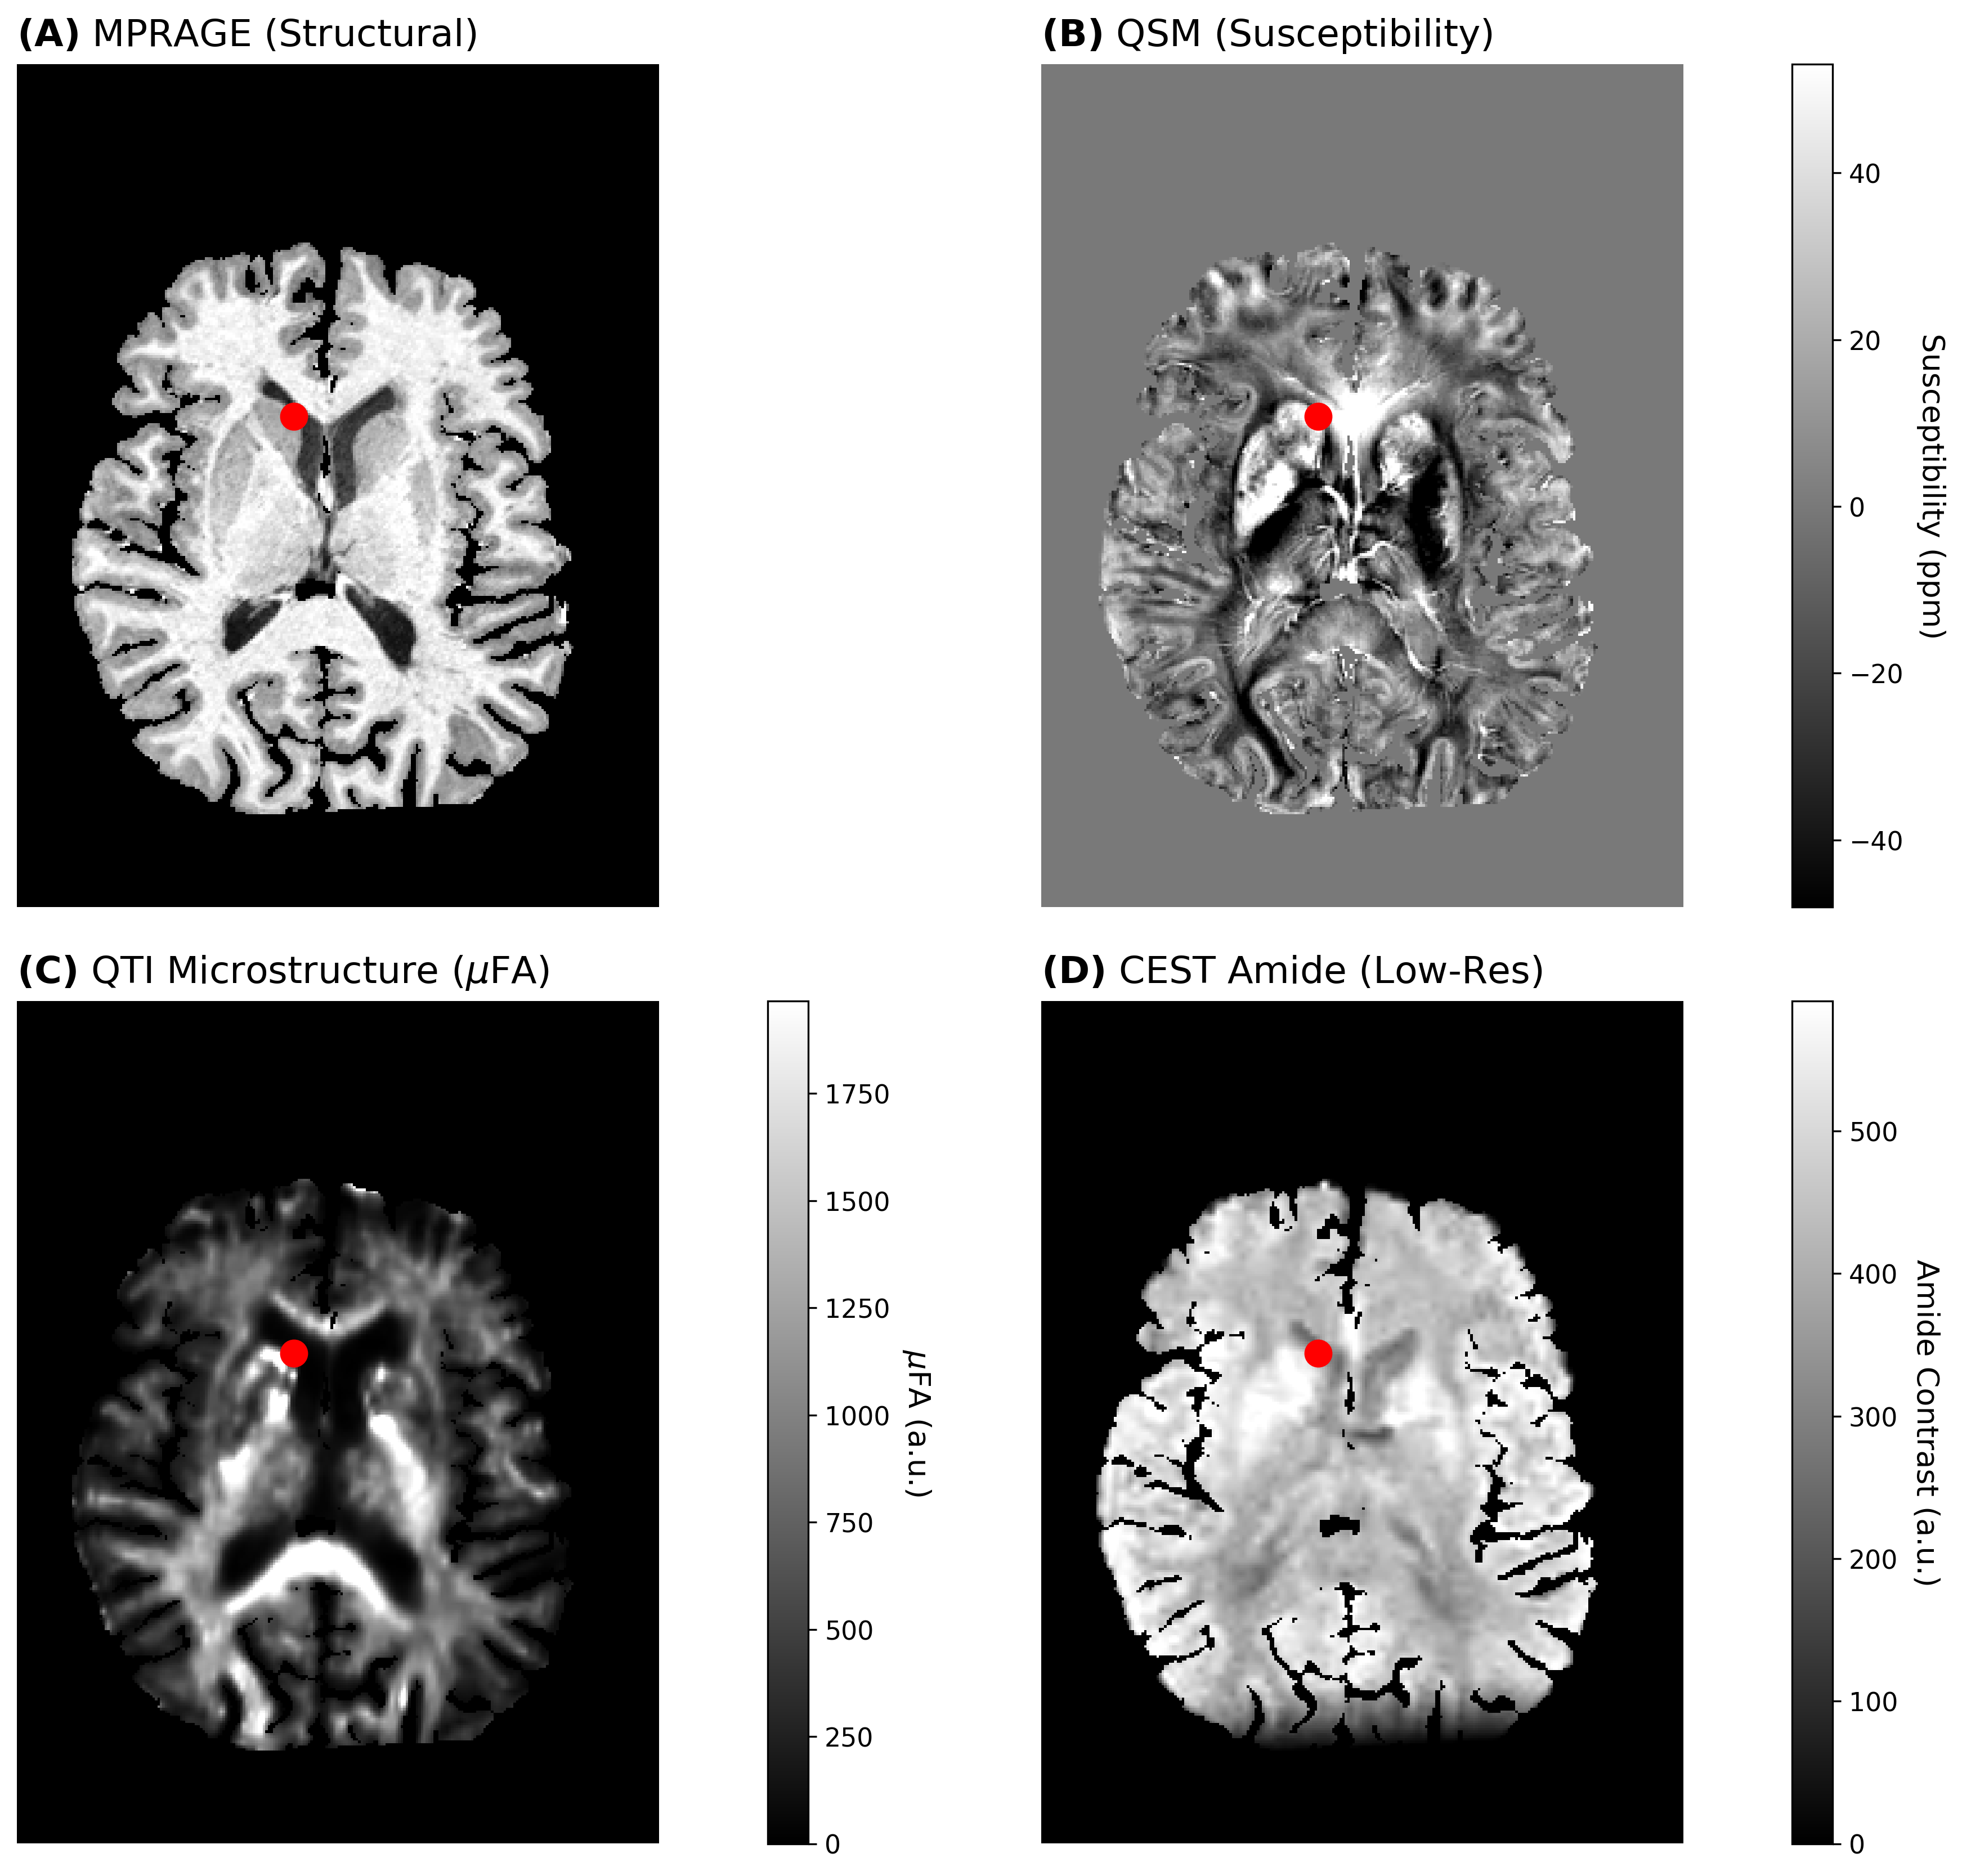

In [23]:


ROTATION_K = 2

marker_xy = (110, 140)          # (x, y) = (列, 行)，你可以自己改
marker_diameter_px = 800        # 直径（像素）

for slice_idx in target_slices:
    try:
        sl_data, _ = get_slice_corrected(data_vol, labels_vol, TARGET_AXIS, slice_idx, ROTATION_K)
        plot_contrasts_2x2(
            sl_data[..., CH_MPRAGE],
            sl_data[..., CH_QSM],
            sl_data[..., CH_UFA],
            sl_data[..., CH_AMIDE],
            title_fs=TITLE_FS, cbar_fs=CBAR_FS, tick_fs=TICK_FS,
            marker_xy=marker_xy,
            marker_diameter_px=800,
        )
    except IndexError as e:
        print(f"❌ 索引错误 (层 {slice_idx}): {e}")
